# Кластерный анализ Ethereum-адресов


In [ ]:
# Установка зависимостей (Google Colab / Kaggle)
!pip install -q kagglehub

In [ ]:
import os, pickle, random, gc
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import kneighbors_graph
from scipy.cluster.hierarchy import linkage, dendrogram

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

## 1. Загрузка данных

In [ ]:
# Если таблица признаков уже была сохранена предыдущей версией работы,
# можно загрузить её и пропустить обработку большого графа.
FEATURES_CSV = "ethereum_phishing_features.csv"

if os.path.exists(FEATURES_CSV):
    df = pd.read_csv(FEATURES_CSV)
    print("Загружена готовая таблица признаков:", df.shape)
else:
    import kagglehub
    dataset_path = kagglehub.dataset_download("xblock/ethereum-phishing-transaction-network")
    candidates = []
    for root, _, files in os.walk(dataset_path):
        if "MulDiGraph.pkl" in files:
            candidates.append(os.path.join(root, "MulDiGraph.pkl"))
    if not candidates:
        raise FileNotFoundError("MulDiGraph.pkl не найден")
    PKL_PATH = candidates[0]
    with open(PKL_PATH, "rb") as f:
        G = pickle.load(f)
    print("Узлов:", G.number_of_nodes(), "Рёбер:", G.number_of_edges())

100%|██████████| 392M/392M [00:02<00:00, 189MB/s]

Extracting files...


Узлов: 2973489 Рёбер: 13551303


## 2. Формирование подграфа и извлечение признаков

In [ ]:
if "df" not in globals():
    phishing_nodes = [n for n,d in G.nodes(data=True) if d.get("isp",0)==1]
    normal_nodes = [n for n,d in G.nodes(data=True) if d.get("isp",0)==0]
    neighbors=set()
    for n in phishing_nodes:
        neighbors.update(G.predecessors(n)); neighbors.update(G.successors(n))
    sampled_neighbors=random.sample(list(neighbors), min(30000,len(neighbors)))
    sampled_normal=random.sample(normal_nodes, min(30000,len(normal_nodes)))
    selected=set(phishing_nodes)|set(sampled_neighbors)|set(sampled_normal)
    subG=G.subgraph(selected).copy()
    print("Подграф:",subG.number_of_nodes(),"узлов,",subG.number_of_edges(),"рёбер")

    def stats(v):
        a=np.asarray(v,dtype=float)
        if len(a)==0: return 0.,0.,0.,0.,0.
        return float(a.sum()),float(a.mean()),float(a.std()),float(a.min()),float(a.max())

    def extract(graph,node):
        ine=list(graph.in_edges(node,data=True)); oute=list(graph.out_edges(node,data=True))
        ia=[float(d.get('amount',0)) for *_,d in ine]; oa=[float(d.get('amount',0)) for *_,d in oute]
        it=[float(d.get('timestamp',0)) for *_,d in ine]; ot=[float(d.get('timestamp',0)) for *_,d in oute]
        isum,imean,istd,imin,imax=stats(ia); osum,omean,ostd,omin,omax=stats(oa)
        times=it+ot; tmin=min(times) if times else 0; tmax=max(times) if times else 0
        preds=set(graph.predecessors(node)); succs=set(graph.successors(node))
        return dict(in_count=len(ine),out_count=len(oute),total_count=len(ine)+len(oute),
          in_sum=isum,out_sum=osum,total_sum=isum+osum,in_mean=imean,out_mean=omean,
          in_std=istd,out_std=ostd,in_min=imin,out_min=omin,in_max=imax,out_max=omax,
          in_degree=graph.in_degree(node),out_degree=graph.out_degree(node),total_degree=graph.degree(node),
          unique_predecessors=len(preds),unique_successors=len(succs),unique_neighbors=len(preds|succs),
          time_min=tmin,time_max=tmax,time_span=tmax-tmin,
          in_time_std=float(np.std(it)) if it else 0.,out_time_std=float(np.std(ot)) if ot else 0.)

    rows=[]
    for i,n in enumerate(subG.nodes()):
        r=extract(subG,n); r['address']=n; r['label']=subG.nodes[n].get('isp',0); rows.append(r)
        if i and i%5000==0: print('Обработано:',i)
    df=pd.DataFrame(rows).replace([np.inf,-np.inf],np.nan).fillna(0)
    df.to_csv(FEATURES_CSV,index=False)
    del G; gc.collect()
print(df.shape, df['label'].value_counts().to_dict())

Подграф: 59190 узлов, 1337643 рёбер
Обработано: 5000
Обработано: 10000
Обработано: 15000
Обработано: 20000
Обработано: 25000
Обработано: 30000
Обработано: 35000
Обработано: 40000
Обработано: 45000
Обработано: 50000
Обработано: 55000
(59190, 27) {0: 58025, 1: 1165}


## 3. Подготовка признакового пространства

Кластеризация выполняется по тем же поведенческим признакам, которые ранее использовались для классификации. Они вычисляются из параметров рёбер `amount`, `timestamp` и структуры направленного мультиграфа. Метка `label` (`isp`) в кластеризацию не передаётся и используется только после получения кластеров.

**Интенсивность операций:** `in_count`, `out_count`, `total_count`.

**Денежные потоки:** `in_sum`, `out_sum`, `total_sum`, `in_mean`, `out_mean`, `in_std`, `out_std`, `in_min`, `out_min`, `in_max`, `out_max`.

**Структура связей:** `in_degree`, `out_degree`, `total_degree`, `unique_predecessors`, `unique_successors`, `unique_neighbors`.

**Временная активность:** `time_min`, `time_max`, `time_span`, `in_time_std`, `out_time_std`. При этом абсолютные календарные метки `time_min` и `time_max` рассчитываются и сохраняются в таблице, но исключаются из кластеризации. Используются `time_span`, `in_time_std` и `out_time_std`, характеризующие продолжительность и концентрацию активности.

Перед стандартизацией к неотрицательным признакам применяется `log1p`, затем выполняется `StandardScaler`. Это уменьшает влияние экстремально активных адресов и приводит признаки к сопоставимому масштабу.


In [ ]:
# Полный перечень признаков, использовавшихся ранее при классификации,
# сохраняется и применяется теперь для кластерного анализа.
feature_cols = [c for c in df.columns if c not in ['address', 'label', 'cluster']]
X = df[feature_cols].copy()

# time_min и time_max — абсолютные календарные метки. Они исключаются,
# поскольку могут разделять адреса преимущественно по периоду наблюдения,
# а не по устойчивому типу транзакционного поведения.
for c in ['time_min', 'time_max']:
    if c in X.columns:
        X = X.drop(columns=c)

# Сжимаем правосторонне асимметричные неотрицательные распределения.
for c in X.columns:
    if (X[c] >= 0).all():
        X[c] = np.log1p(X[c])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Признаки кластеризации:', list(X.columns))
print('Матрица кластеризации:', X_scaled.shape)


Признаки кластеризации: ['in_count', 'out_count', 'total_count', 'in_sum', 'out_sum', 'total_sum', 'in_mean', 'out_mean', 'in_std', 'out_std', 'in_min', 'out_min', 'in_max', 'out_max', 'in_degree', 'out_degree', 'total_degree', 'unique_predecessors', 'unique_successors', 'unique_neighbors', 'time_span', 'in_time_std', 'out_time_std']
Матрица кластеризации: (59190, 23)


## 4. Определение числа кластеров методом локтя

Для метода K-средних заранее задаётся число кластеров. В работе проверяются значения `k` от 2 до 8, и для каждого варианта рассчитывается **inertia (WCSS)** — сумма квадратов расстояний объектов до центроидов.

Оптимальное число кластеров определяется по точке изменения наклона кривой. По полученному графику область локтя соответствует `k = 4`, поэтому дальнейшее разбиение строится на четыре кластера.


In [ ]:
K_VALUES = list(range(2, 9))

rows = []
for k in K_VALUES:
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        max_iter=300,
        random_state=RANDOM_STATE
    )
    model.fit(X_scaled)
    rows.append({
        "k": k,
        "inertia": model.inertia_
    })

k_metrics = pd.DataFrame(rows)
display(k_metrics.round(4))

BEST_K = 4
print("По методу локтя выбрано число кластеров:", BEST_K)


,k,inertia
0,2,921564.1085
1,3,765294.2294
2,4,666734.7616
3,5,586244.4187
4,6,519448.9221
5,7,465836.7760
6,8,427845.5949


По методу локтя выбрано число кластеров: 4


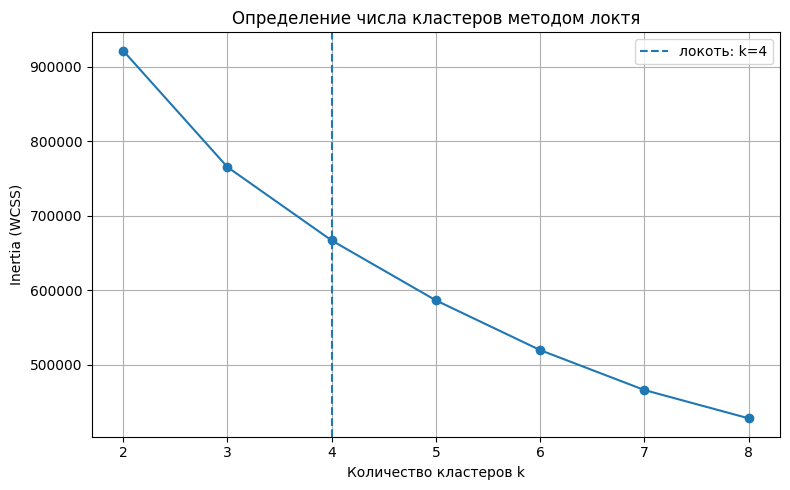

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_metrics["k"], k_metrics["inertia"], marker="o")
plt.axvline(BEST_K, linestyle="--", label=f"локоть: k={BEST_K}")
plt.title("Определение числа кластеров методом локтя")
plt.xlabel("Количество кластеров k")
plt.ylabel("Inertia (WCSS)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("01_elbow_method.png", dpi=200, bbox_inches="tight")
plt.show()

k_metrics.to_csv("k_selection_inertia.csv", index=False)


## 5. Определение числа кластеров методом силуэта

Метод силуэта оценивает, насколько объект близок к своему кластеру и удалён от ближайшего соседнего кластера. Коэффициент принимает значения от −1 до 1: чем он выше, тем лучше выражено разбиение. Для ускорения расчёта при большой выборке используется случайная подвыборка, одинаковая для всех значений `k`.


,k,silhouette_score
0,2,0.4696
1,3,0.4190
2,4,0.4347
3,5,0.3441
4,6,0.3633
5,7,0.3752
6,8,0.3956


По методу силуэта рекомендуется число кластеров: 2


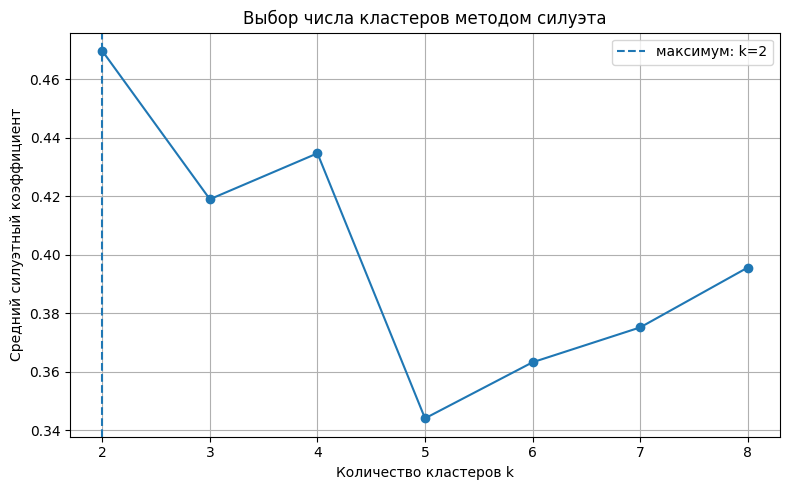

In [ ]:
SILHOUETTE_SAMPLE_SIZE = min(10000, len(df))
silhouette_rng = np.random.RandomState(RANDOM_STATE)
silhouette_idx = silhouette_rng.choice(
    len(df), SILHOUETTE_SAMPLE_SIZE, replace=False
)
X_silhouette = X_scaled[silhouette_idx]

silhouette_rows = []
for k in K_VALUES:
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        max_iter=300,
        random_state=RANDOM_STATE
    )
    labels = model.fit_predict(X_silhouette)
    score = silhouette_score(X_silhouette, labels)
    silhouette_rows.append({"k": k, "silhouette_score": score})

silhouette_metrics = pd.DataFrame(silhouette_rows)
K_SILHOUETTE = int(
    silhouette_metrics.loc[
        silhouette_metrics["silhouette_score"].idxmax(), "k"
    ]
)

display(silhouette_metrics.round(4))
print("По методу силуэта рекомендуется число кластеров:", K_SILHOUETTE)

plt.figure(figsize=(8, 5))
plt.plot(
    silhouette_metrics["k"],
    silhouette_metrics["silhouette_score"],
    marker="o"
)
plt.axvline(
    K_SILHOUETTE,
    linestyle="--",
    label=f"максимум: k={K_SILHOUETTE}"
)
plt.title("Выбор числа кластеров методом силуэта")
plt.xlabel("Количество кластеров k")
plt.ylabel("Средний силуэтный коэффициент")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("02_silhouette_method.png", dpi=200, bbox_inches="tight")
plt.show()

silhouette_metrics.to_csv("k_selection_silhouette.csv", index=False)


**Нумерация кластеров.** Внутри алгоритма K-means метки имеют значения от 0 до k−1. Для таблиц, графиков и отчёта к ним прибавляется 1, поэтому пользовательская нумерация начинается с кластера 1.

In [ ]:
kmeans = KMeans(
    n_clusters=BEST_K,
    init="k-means++",
    n_init=20,
    max_iter=300,
    random_state=RANDOM_STATE
)

cluster_labels_zero_based = kmeans.fit_predict(X_scaled)
df["cluster"] = cluster_labels_zero_based + 1

quality = pd.DataFrame({
    "Метрика": ["Inertia"],
    "Значение": [kmeans.inertia_]
})
display(quality.round(4))

print("Итоговый алгоритм: K-средних")
print("Итоговое число кластеров:", BEST_K)


,Метрика,Значение
0,Inertia,666734.7616


Итоговый алгоритм: K-средних
Итоговое число кластеров: 4


## 7. Состав кластеров и распределение фишинговых адресов

После завершения кластеризации к результату присоединяется исходная метка `label`. Для каждого кластера рассчитываются общее число адресов, число известных фишинговых адресов, доля фишинга внутри кластера, доля всех фишинговых адресов выборки и коэффициент концентрации относительно всей выборки.

,cluster,total_addresses,phishing_addresses,normal_addresses,cluster_share_pct,phishing_share_pct,share_of_all_phishing_pct,enrichment_vs_dataset
0,1,2659,334,2325,4.4923,12.5611,28.6695,6.3819
1,2,38252,182,38070,64.6258,0.4758,15.6223,0.2417
2,3,12982,308,12674,21.9328,2.3725,26.4378,1.2054
3,4,5297,341,4956,8.9491,6.4376,29.2704,3.2707


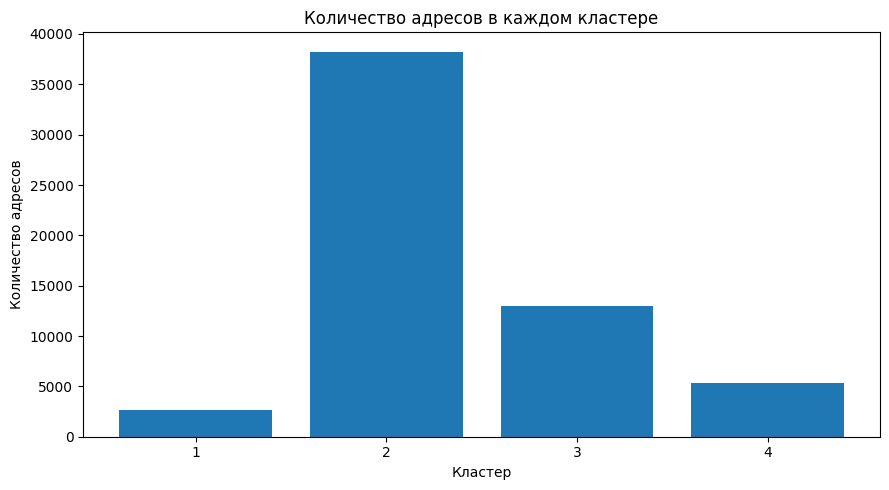

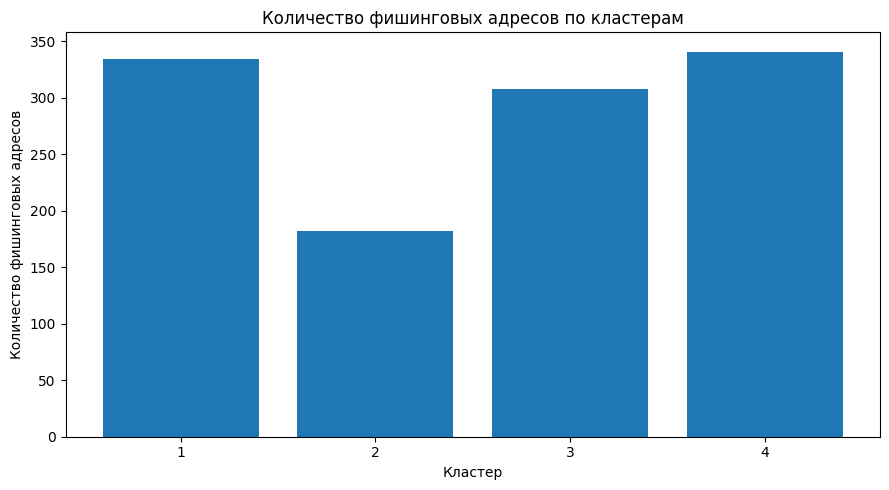

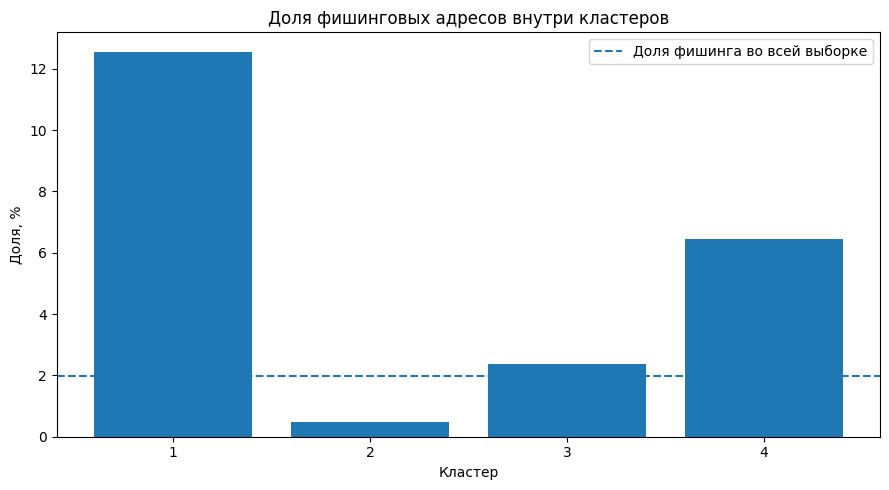

In [ ]:
cluster_summary = (df.groupby('cluster').agg(
    total_addresses=('label', 'size'),
    phishing_addresses=('label', 'sum')
).reset_index())

cluster_summary['normal_addresses'] = (
    cluster_summary['total_addresses'] - cluster_summary['phishing_addresses']
)
cluster_summary['cluster_share_pct'] = (
    100 * cluster_summary['total_addresses'] / len(df)
)
cluster_summary['phishing_share_pct'] = (
    100 * cluster_summary['phishing_addresses'] / cluster_summary['total_addresses']
)
cluster_summary['share_of_all_phishing_pct'] = (
    100 * cluster_summary['phishing_addresses'] / df['label'].sum()
)
overall_rate = df['label'].mean()
cluster_summary['enrichment_vs_dataset'] = (
    (cluster_summary['phishing_addresses'] / cluster_summary['total_addresses']) / overall_rate
)
cluster_summary = cluster_summary.sort_values('cluster').reset_index(drop=True)
display(cluster_summary.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(cluster_summary['cluster'].astype(str), cluster_summary['total_addresses'])
ax.set_title('Количество адресов в каждом кластере')
ax.set_xlabel('Кластер')
ax.set_ylabel('Количество адресов')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(cluster_summary['cluster'].astype(str), cluster_summary['phishing_addresses'])
ax.set_title('Количество фишинговых адресов по кластерам')
ax.set_xlabel('Кластер')
ax.set_ylabel('Количество фишинговых адресов')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(cluster_summary['cluster'].astype(str), cluster_summary['phishing_share_pct'])
ax.axhline(overall_rate * 100, linestyle='--', label='Доля фишинга во всей выборке')
ax.set_title('Доля фишинговых адресов внутри кластеров')
ax.set_xlabel('Кластер')
ax.set_ylabel('Доля, %')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Отличительные признаки каждого кластера

Профиль кластера определяется по средним стандартизированным значениям признаков. Значение выше нуля означает, что признак в кластере выше среднего по выборке; значение ниже нуля — ниже среднего. Для каждого кластера автоматически выводятся признаки с наибольшим абсолютным отклонением от среднего.

,in_count,out_count,total_count,in_sum,out_sum,total_sum,in_mean,out_mean,in_std,out_std,...,out_max,in_degree,out_degree,total_degree,unique_predecessors,unique_successors,unique_neighbors,time_span,in_time_std,out_time_std
cluster,,,,,,,,,,,,,,,,,,,,,
1,1.832,1.902,1.930,2.980,3.055,3.022,1.978,1.439,2.977,2.931,...,2.792,1.832,1.902,1.930,1.720,1.612,1.764,1.092,1.495,1.217
2,-0.477,-0.402,-0.515,-0.426,-0.310,-0.444,-0.345,-0.206,-0.302,-0.231,...,-0.294,-0.477,-0.402,-0.515,-0.456,-0.399,-0.509,-0.449,-0.535,-0.366
3,1.001,0.992,1.220,0.184,-0.004,0.145,-0.097,-0.238,0.065,-0.005,...,-0.074,1.001,0.992,1.220,0.937,1.038,1.227,1.077,1.250,1.018
4,0.072,-0.480,-0.236,1.126,0.714,1.331,1.738,1.347,0.530,0.209,...,0.901,0.072,-0.480,-0.236,0.135,-0.474,-0.214,0.059,0.048,-0.461


,in_count,out_count,total_count,in_sum,out_sum,total_sum,in_mean,out_mean,in_std,out_std,...,out_max,in_degree,out_degree,total_degree,unique_predecessors,unique_successors,unique_neighbors,time_span,in_time_std,out_time_std
cluster,,,,,,,,,,,,,,,,,,,,,
1,153.200,337.289,490.489,1877.298,1942.922,3820.220,71.358,18.453,102.968,29.505,...,304.135,153.200,337.289,490.489,20.902,35.589,54.022,2.250122e+07,4812225.826,4795917.750
2,0.460,1.471,1.931,0.180,0.313,0.493,0.136,0.213,0.015,0.038,...,0.266,0.460,1.471,1.931,0.372,1.034,1.385,1.333713e+06,80593.964,408200.175
3,69.284,29.113,98.398,4.707,1.426,6.133,0.486,0.151,0.413,0.195,...,0.704,69.284,29.113,98.398,15.712,11.050,26.281,1.652747e+07,3552413.645,3485796.738
4,2.498,1.240,3.739,37.826,11.967,49.793,19.613,8.899,4.359,1.008,...,10.213,2.498,1.240,3.739,1.628,0.903,2.509,3.201733e+06,612250.542,398017.891


Кластер 1: наиболее отличительные признаки
  out_sum: выше среднего на 3.06 стандартного отклонения
  total_sum: выше среднего на 3.02 стандартного отклонения
  in_sum: выше среднего на 2.98 стандартного отклонения
  in_std: выше среднего на 2.98 стандартного отклонения
  out_std: выше среднего на 2.93 стандартного отклонения
  out_max: выше среднего на 2.79 стандартного отклонения
  in_max: выше среднего на 2.72 стандартного отклонения
  in_mean: выше среднего на 1.98 стандартного отклонения
Кластер 2: наиболее отличительные признаки
  in_time_std: ниже среднего на 0.53 стандартного отклонения
  total_degree: ниже среднего на 0.52 стандартного отклонения
  total_count: ниже среднего на 0.52 стандартного отклонения
  unique_neighbors: ниже среднего на 0.51 стандартного отклонения
  in_degree: ниже среднего на 0.48 стандартного отклонения
  in_count: ниже среднего на 0.48 стандартного отклонения
  unique_predecessors: ниже среднего на 0.46 стандартного отклонения
  time_span: ниже средн

,cluster,feature,standardized_mean,direction,raw_mean
0,1,out_sum,3.0552,выше среднего,1.942922e+03
1,1,total_sum,3.0220,выше среднего,3.820220e+03
2,1,in_sum,2.9800,выше среднего,1.877298e+03
3,1,in_std,2.9770,выше среднего,1.029677e+02
4,1,out_std,2.9310,выше среднего,2.950540e+01
5,1,out_max,2.7924,выше среднего,3.041352e+02
6,1,in_max,2.7191,выше среднего,3.688199e+02
7,1,in_mean,1.9782,выше среднего,7.135760e+01
8,2,in_time_std,-0.5349,ниже среднего,8.059396e+04
9,2,total_degree,-0.5154,ниже среднего,1.931200e+00


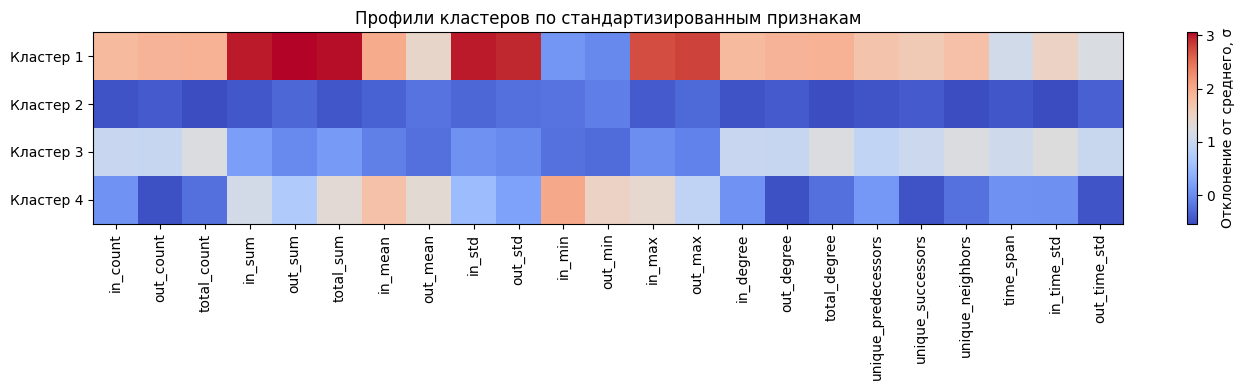

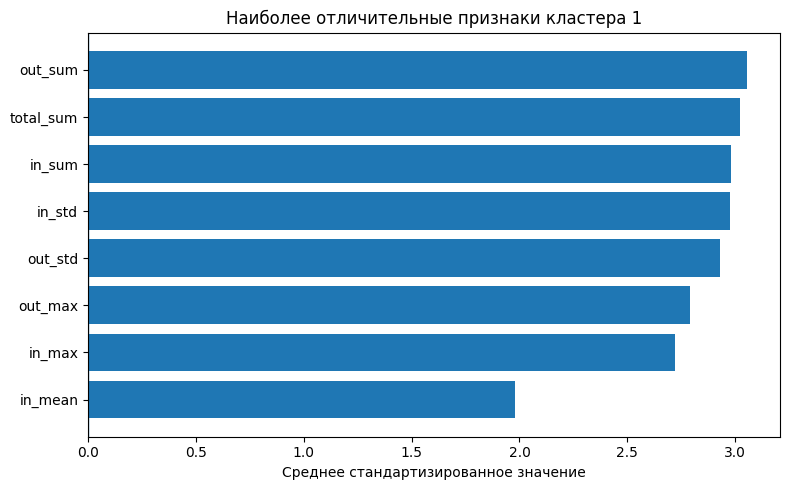

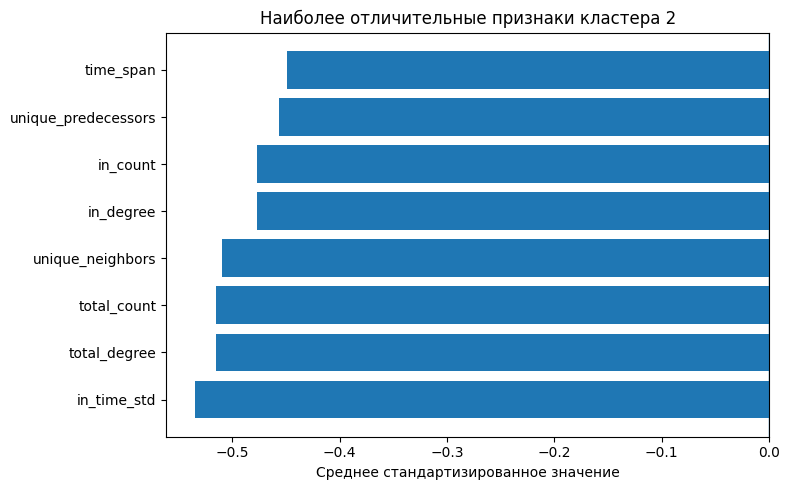

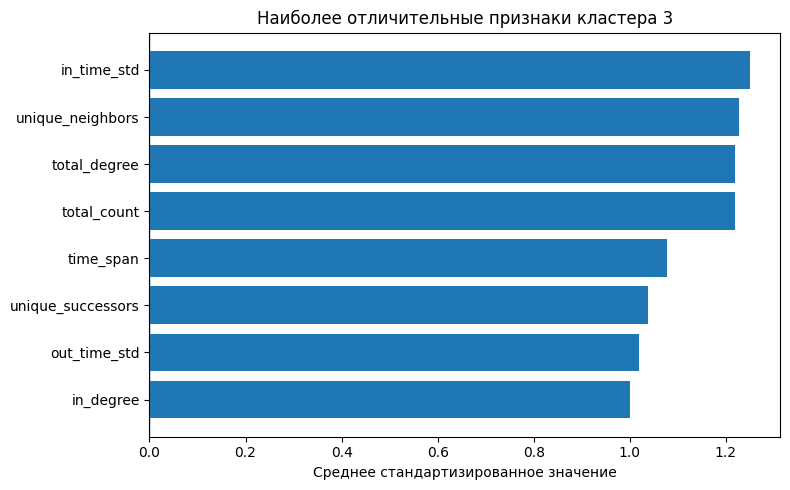

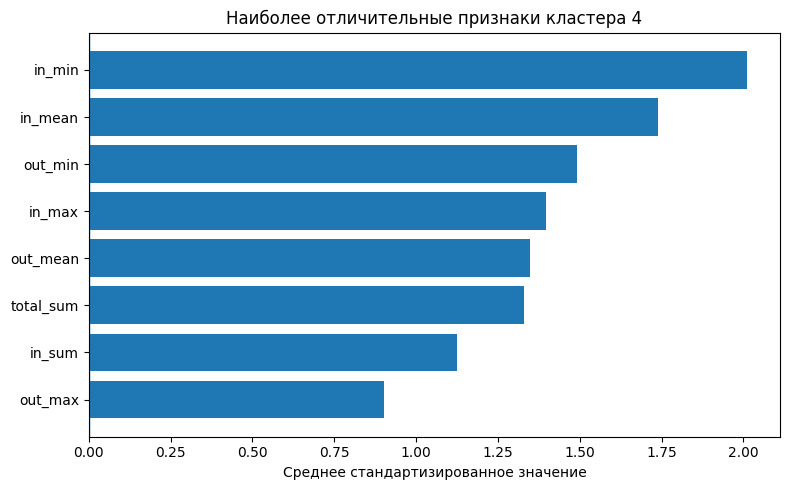

In [ ]:
scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=df.index)
scaled_df['cluster'] = df['cluster'].to_numpy()
profiles = scaled_df.groupby('cluster').mean()
profiles.index.name = 'cluster'

# Средние значения в исходном масштабе нужны для содержательной интерпретации.
raw_profiles = df.groupby('cluster')[list(X.columns)].mean()

display(profiles.round(3))
display(raw_profiles.round(3))

DISTINCTIVE_TOP_N = 8
distinctive_rows = []
for cl in profiles.index:
    s = profiles.loc[cl]
    top_features = s.abs().sort_values(ascending=False).head(DISTINCTIVE_TOP_N).index
    print(f'Кластер {cl}: наиболее отличительные признаки')
    for feature in top_features:
        z = s[feature]
        direction = 'выше среднего' if z > 0 else 'ниже среднего'
        distinctive_rows.append({
            'cluster': cl,
            'feature': feature,
            'standardized_mean': z,
            'direction': direction,
            'raw_mean': raw_profiles.loc[cl, feature]
        })
        print(f'  {feature}: {direction} на {abs(z):.2f} стандартного отклонения')

distinctive_features = pd.DataFrame(distinctive_rows)
display(distinctive_features.round(4))

fig, ax = plt.subplots(figsize=(14, max(4, 0.8 * len(profiles))))
im = ax.imshow(profiles.to_numpy(), aspect='auto', cmap='coolwarm')
ax.set_yticks(range(len(profiles)))
ax.set_yticklabels([f'Кластер {i}' for i in profiles.index])
ax.set_xticks(range(len(profiles.columns)))
ax.set_xticklabels(profiles.columns, rotation=90)
ax.set_title('Профили кластеров по стандартизированным признакам')
plt.colorbar(im, ax=ax, label='Отклонение от среднего, σ')
plt.tight_layout()
plt.show()

# Отдельный график наиболее отличительных признаков каждого кластера.
for cl in profiles.index:
    part = distinctive_features[distinctive_features['cluster'] == cl].copy()
    part = part.sort_values('standardized_mean')
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(part['feature'], part['standardized_mean'])
    ax.axvline(0, linewidth=1)
    ax.set_title(f'Наиболее отличительные признаки кластера {cl}')
    ax.set_xlabel('Среднее стандартизированное значение')
    plt.tight_layout()
    plt.show()

## 9. Визуализация итогового разбиения

Для наглядного представления многомерного разбиения признаки проецируются на две главные компоненты PCA. Эта визуализация не участвует в обучении K-средних и используется только для анализа результата.

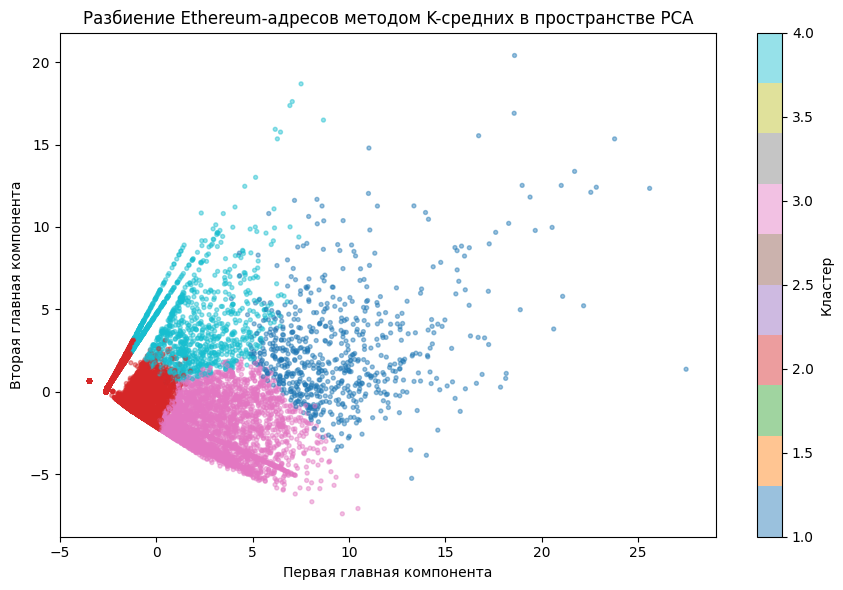

Доля дисперсии, объяснённая двумя компонентами: 0.6693837331555494


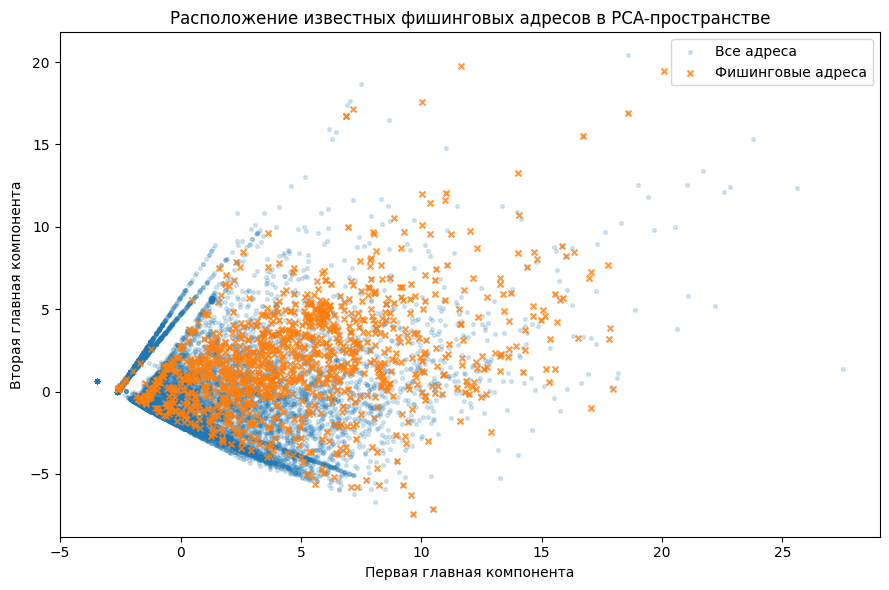

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
plot_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(df), min(15000, len(df)), replace=False
)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    X_pca[plot_idx, 0], X_pca[plot_idx, 1],
    c=df.iloc[plot_idx]['cluster'], s=8, alpha=0.45, cmap='tab10'
)
ax.set_title('Разбиение Ethereum-адресов методом K-средних в пространстве PCA')
ax.set_xlabel('Первая главная компонента')
ax.set_ylabel('Вторая главная компонента')
plt.colorbar(sc, ax=ax, label='Кластер')
plt.tight_layout()
plt.show()
print('Доля дисперсии, объяснённая двумя компонентами:', pca.explained_variance_ratio_.sum())

# Фишинговые адреса поверх общей PCA-проекции.
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X_pca[plot_idx, 0], X_pca[plot_idx, 1], s=7, alpha=0.18, label='Все адреса')
ph_idx = np.where(df['label'].to_numpy() == 1)[0]
ax.scatter(X_pca[ph_idx, 0], X_pca[ph_idx, 1], s=18, alpha=0.8, marker='x', label='Фишинговые адреса')
ax.set_title('Расположение известных фишинговых адресов в PCA-пространстве')
ax.set_xlabel('Первая главная компонента')
ax.set_ylabel('Вторая главная компонента')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Альтернативная кластеризация методом Уорда

Метод Уорда относится к агломеративной иерархической кластеризации. На каждом шаге объединяются два кластера, слияние которых вызывает минимальное увеличение внутрикластерной суммы квадратов. Из-за высокой вычислительной сложности метод применяется к общей контрольной подвыборке. Это позволяет сопоставить его с K-средних по силуэтному коэффициенту и по распределению известных фишинговых адресов.


/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:325: UserWarning: the number of connected components of the connectivity matrix is 2 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:325: UserWarning: the number of connected components of the connectivity matrix is 2 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:325: UserWarning: the number of connected components of the connectivity matrix is 2 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:325: UserWarning: the number of connected components of the connectivity matrix is 2 > 1. Completing it to avo

,method,k,silhouette_score
0,K-средних,2,0.4696
1,Метод Уорда,2,0.4467
2,K-средних,3,0.4190
3,Метод Уорда,3,0.4147
4,K-средних,4,0.4347
5,Метод Уорда,4,0.3958
6,K-средних,5,0.3441
7,Метод Уорда,5,0.4022
8,K-средних,6,0.3633
9,Метод Уорда,6,0.4067


Лучшее число кластеров для метода Уорда по силуэту: 2


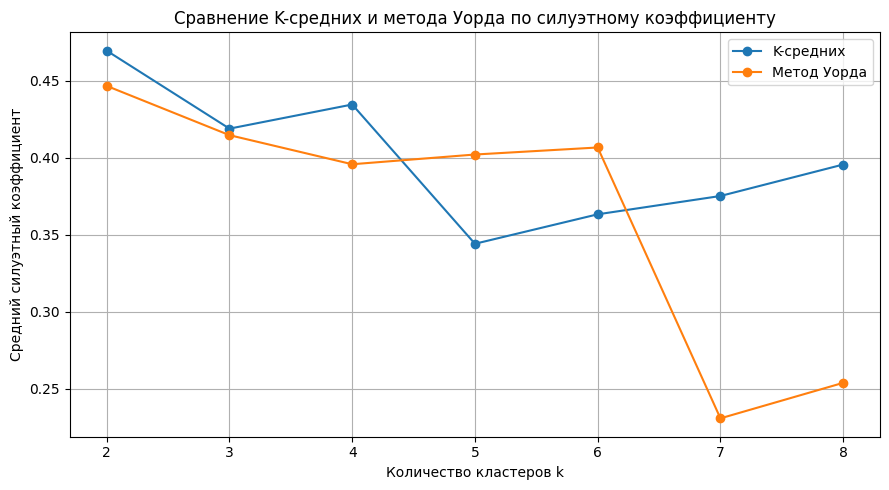

,ward_cluster,total_addresses,phishing_addresses,phishing_share_pct,share_of_all_phishing_in_sample_pct,enrichment_vs_sample
0,1,2209,87,3.9384,45.7895,2.0729
1,2,7791,103,1.3220,54.2105,0.6958


,in_count,out_count,total_count,in_sum,out_sum,total_sum,in_mean,out_mean,in_std,out_std,...,out_max,in_degree,out_degree,total_degree,unique_predecessors,unique_successors,unique_neighbors,time_span,in_time_std,out_time_std
ward_cluster,,,,,,,,,,,,,,,,,,,,,
1,1.265,1.380,1.530,0.788,0.563,0.706,0.316,0.007,0.687,0.506,...,0.425,1.265,1.380,1.530,1.219,1.402,1.579,1.099,1.319,1.129
2,-0.337,-0.378,-0.417,-0.225,-0.165,-0.207,-0.104,-0.016,-0.200,-0.162,...,-0.132,-0.337,-0.378,-0.417,-0.316,-0.378,-0.417,-0.314,-0.357,-0.328


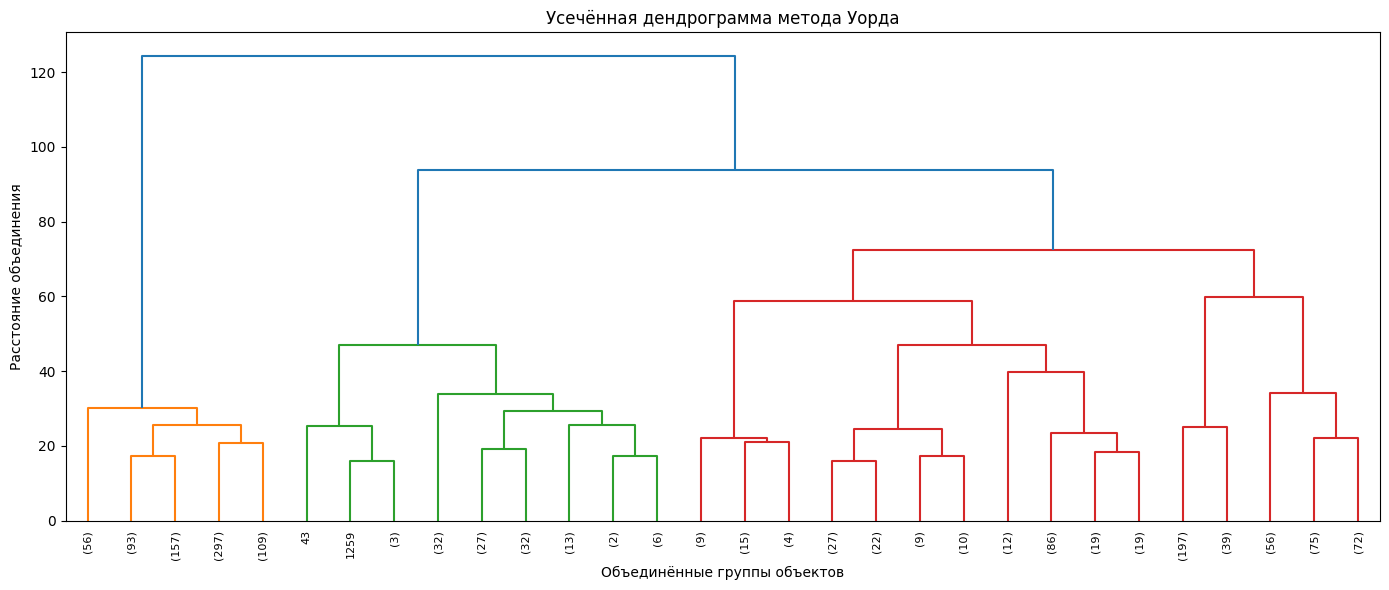

In [ ]:
WARD_SAMPLE_SIZE = min(10000, len(df))
ward_rng = np.random.RandomState(RANDOM_STATE)
ward_idx = ward_rng.choice(len(df), WARD_SAMPLE_SIZE, replace=False)
X_ward = X_scaled[ward_idx]
ward_df = df.iloc[ward_idx].copy().reset_index(drop=True)

# Для одного и того же набора объектов сравниваем K-средних и метод Уорда.
comparison_rows = []
ward_results = {}

for k in K_VALUES:
    # K-средних на контрольной подвыборке
    km_sample = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        max_iter=300,
        random_state=RANDOM_STATE
    )
    km_labels = km_sample.fit_predict(X_ward)
    comparison_rows.append({
        "method": "K-средних",
        "k": k,
        "silhouette_score": silhouette_score(X_ward, km_labels)
    })

    # Метод Уорда. Матрица соседства ограничивает возможные объединения
    # и делает расчёт более устойчивым для крупной подвыборки.
    connectivity = kneighbors_graph(
        X_ward,
        n_neighbors=min(20, len(X_ward) - 1),
        include_self=False
    )
    ward_model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward",
        connectivity=connectivity
    )
    ward_labels = ward_model.fit_predict(X_ward)
    ward_score = silhouette_score(X_ward, ward_labels)
    comparison_rows.append({
        "method": "Метод Уорда",
        "k": k,
        "silhouette_score": ward_score
    })
    ward_results[k] = ward_labels

method_comparison = pd.DataFrame(comparison_rows)
display(method_comparison.round(4))

best_ward_row = method_comparison[
    method_comparison["method"] == "Метод Уорда"
].loc[lambda x: x["silhouette_score"].idxmax()]
WARD_BEST_K = int(best_ward_row["k"])
print("Лучшее число кластеров для метода Уорда по силуэту:", WARD_BEST_K)

plt.figure(figsize=(9, 5))
for method, part in method_comparison.groupby("method"):
    plt.plot(part["k"], part["silhouette_score"], marker="o", label=method)
plt.title("Сравнение K-средних и метода Уорда по силуэтному коэффициенту")
plt.xlabel("Количество кластеров k")
plt.ylabel("Средний силуэтный коэффициент")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("10_kmeans_vs_ward_silhouette.png", dpi=200, bbox_inches="tight")
plt.show()

# Итоговое разбиение Уорда на выбранное число кластеров.
ward_df["ward_cluster"] = ward_results[WARD_BEST_K] + 1
ward_summary = (
    ward_df.groupby("ward_cluster")
    .agg(
        total_addresses=("label", "size"),
        phishing_addresses=("label", "sum")
    )
    .reset_index()
)
ward_summary["phishing_share_pct"] = (
    100 * ward_summary["phishing_addresses"] / ward_summary["total_addresses"]
)
ward_summary["share_of_all_phishing_in_sample_pct"] = (
    100 * ward_summary["phishing_addresses"] / ward_df["label"].sum()
)
ward_overall_rate = ward_df["label"].mean()
ward_summary["enrichment_vs_sample"] = (
    ward_summary["phishing_addresses"] / ward_summary["total_addresses"]
) / ward_overall_rate

display(ward_summary.round(4))

ward_scaled_df = pd.DataFrame(X_ward, columns=X.columns)
ward_scaled_df["ward_cluster"] = ward_df["ward_cluster"].to_numpy()
ward_profiles = ward_scaled_df.groupby("ward_cluster").mean()
display(ward_profiles.round(3))

# Дендограмма строится на меньшей подвыборке только для визуализации иерархии.
DENDROGRAM_SIZE = min(1500, len(X_ward))
dendrogram_idx = ward_rng.choice(len(X_ward), DENDROGRAM_SIZE, replace=False)
Z = linkage(X_ward[dendrogram_idx], method="ward")
plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=8)
plt.title("Усечённая дендрограмма метода Уорда")
plt.xlabel("Объединённые группы объектов")
plt.ylabel("Расстояние объединения")
plt.tight_layout()
plt.savefig("11_ward_dendrogram.png", dpi=200, bbox_inches="tight")
plt.show()

method_comparison.to_csv("kmeans_vs_ward_silhouette.csv", index=False)
ward_summary.to_csv("ward_cluster_phishing_summary.csv", index=False)
ward_profiles.to_csv("ward_cluster_profiles_standardized.csv")


## 11. Автоматическое формирование основы для анализа и сохранение результатов

In [ ]:
# Определяем кластер с наибольшей долей фишинга и кластер,
# в который попало больше всего известных фишинговых адресов.
max_rate_row = cluster_summary.loc[cluster_summary['phishing_share_pct'].idxmax()]
max_count_row = cluster_summary.loc[cluster_summary['phishing_addresses'].idxmax()]

print('ОСНОВА ДЛЯ АНАЛИЗА РЕЗУЛЬТАТОВ')
print(f"1. Выбрано k = {BEST_K} кластеров методом K-средних.")
print(
    f"2. Наибольшее число фишинговых адресов находится в кластере "
    f"{int(max_count_row['cluster'])}: {int(max_count_row['phishing_addresses'])} адресов, "
    f"или {max_count_row['share_of_all_phishing_pct']:.2f}% всех известных фишинговых адресов."
)
print(
    f"3. Наибольшая доля фишинга внутри кластера наблюдается в кластере "
    f"{int(max_rate_row['cluster'])}: {max_rate_row['phishing_share_pct']:.4f}%."
)
print(
    f"4. Его коэффициент концентрации относительно всей выборки равен "
    f"{max_rate_row['enrichment_vs_dataset']:.2f}."
)
print('5. Отличительные признаки каждого кластера приведены в distinctive_features.')

df.to_csv('ethereum_addresses_with_clusters.csv', index=False)
k_metrics.to_csv('kmeans_k_selection_metrics.csv', index=False)
quality.to_csv('kmeans_final_quality.csv', index=False)
cluster_summary.to_csv('cluster_phishing_summary.csv', index=False)
profiles.to_csv('cluster_profiles_standardized.csv')
raw_profiles.to_csv('cluster_profiles_original_scale.csv')
distinctive_features.to_csv('cluster_distinctive_features.csv', index=False)

with open('kmeans_choice.txt', 'w', encoding='utf-8') as f:
    f.write(f'Алгоритм: K-средних\nЧисло кластеров: {BEST_K}\n')

print('Все результаты сохранены.')

ОСНОВА ДЛЯ АНАЛИЗА РЕЗУЛЬТАТОВ
1. Выбрано k = 4 кластеров методом K-средних.
2. Наибольшее число фишинговых адресов находится в кластере 4: 341 адресов, или 29.27% всех известных фишинговых адресов.
3. Наибольшая доля фишинга внутри кластера наблюдается в кластере 1: 12.5611%.
4. Его коэффициент концентрации относительно всей выборки равен 6.38.
5. Отличительные признаки каждого кластера приведены в distinctive_features.
Все результаты сохранены.


## Сравнение качества K-средних и метода Уорда

Для корректного сравнения оба метода применяются к одной и той же стандартизированной подвыборке и при одинаковом числе кластеров `k = 4`. Метка фишинга не участвует в кластеризации и используется только после построения кластеров.

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.decomposition import PCA

N_CLUSTERS = 4
COMPARISON_SAMPLE_SIZE = 10000
RANDOM_STATE = 42

n_objects = X_scaled.shape[0]

if n_objects > COMPARISON_SAMPLE_SIZE:
    rng = np.random.default_rng(RANDOM_STATE)
    comparison_indices = rng.choice(
        n_objects,
        size=COMPARISON_SAMPLE_SIZE,
        replace=False
    )
else:
    comparison_indices = np.arange(n_objects)

X_comparison = X_scaled[comparison_indices]
df_comparison = df.iloc[comparison_indices].copy().reset_index(drop=True)

comparison_feature_cols = list(X.columns)

if len(comparison_feature_cols) != X_comparison.shape[1]:
    raise ValueError(
        f'Число названий признаков ({len(comparison_feature_cols)}) '
        f'не совпадает с числом столбцов матрицы ({X_comparison.shape[1]}).'
    )

print('Количество объектов для сравнения:', len(df_comparison))
print('Количество признаков:', X_comparison.shape[1])
print('Признаки сравнения:', comparison_feature_cols)


Количество объектов для сравнения: 10000
Количество признаков: 23
Признаки сравнения: ['in_count', 'out_count', 'total_count', 'in_sum', 'out_sum', 'total_sum', 'in_mean', 'out_mean', 'in_std', 'out_std', 'in_min', 'out_min', 'in_max', 'out_max', 'in_degree', 'out_degree', 'total_degree', 'unique_predecessors', 'unique_successors', 'unique_neighbors', 'time_span', 'in_time_std', 'out_time_std']


### Кластеризация методом K-средних

In [ ]:
start_time = time.perf_counter()

kmeans_comparison = KMeans(
    n_clusters=N_CLUSTERS,
    init='k-means++',
    n_init=20,
    max_iter=500,
    random_state=RANDOM_STATE
)

kmeans_labels_zero = kmeans_comparison.fit_predict(X_comparison)
kmeans_time = time.perf_counter() - start_time

kmeans_labels = kmeans_labels_zero + 1

print('Время выполнения K-средних:', round(kmeans_time, 4), 'с')


Время выполнения K-средних: 0.2829 с


### Кластеризация методом Уорда

In [ ]:
start_time = time.perf_counter()

ward_comparison = AgglomerativeClustering(
    n_clusters=N_CLUSTERS,
    linkage='ward'
)

ward_labels_zero = ward_comparison.fit_predict(X_comparison)
ward_time = time.perf_counter() - start_time

ward_labels = ward_labels_zero + 1

print('Время выполнения метода Уорда:', round(ward_time, 4), 'с')


Время выполнения метода Уорда: 5.0303 с


### Сравнение внутренних метрик качества

In [ ]:
comparison_results = pd.DataFrame({
    'Метод': ['K-средних', 'Метод Уорда'],
    'Silhouette score': [
        silhouette_score(X_comparison, kmeans_labels_zero),
        silhouette_score(X_comparison, ward_labels_zero)
    ],
    'Davies-Bouldin': [
        davies_bouldin_score(X_comparison, kmeans_labels_zero),
        davies_bouldin_score(X_comparison, ward_labels_zero)
    ],
    'Calinski-Harabasz': [
        calinski_harabasz_score(X_comparison, kmeans_labels_zero),
        calinski_harabasz_score(X_comparison, ward_labels_zero)
    ],
    'Время, секунд': [kmeans_time, ward_time]
})

comparison_results = comparison_results.round(4)
display(comparison_results)
comparison_results.to_csv('comparison_kmeans_ward_metrics.csv', index=False)


,Метод,Silhouette score,Davies-Bouldin,Calinski-Harabasz,"Время, секунд"
0,K-средних,0.4297,1.3706,3455.4374,0.2829
1,Метод Уорда,0.3471,1.5938,2819.3296,5.0303


### Автоматическое определение метода с лучшими показателями

In [ ]:
comparison_scored = comparison_results.copy()
comparison_scored['Баллы'] = 0

comparison_scored.loc[comparison_scored['Silhouette score'].idxmax(), 'Баллы'] += 1
comparison_scored.loc[comparison_scored['Davies-Bouldin'].idxmin(), 'Баллы'] += 1
comparison_scored.loc[comparison_scored['Calinski-Harabasz'].idxmax(), 'Баллы'] += 1
comparison_scored.loc[comparison_scored['Время, секунд'].idxmin(), 'Баллы'] += 1

display(comparison_scored)

winner = comparison_scored.loc[
    comparison_scored['Баллы'].idxmax(),
    'Метод'
]

print('По совокупности численных показателей лучше справился метод:', winner)
comparison_scored.to_csv('comparison_kmeans_ward_scored.csv', index=False)


,Метод,Silhouette score,Davies-Bouldin,Calinski-Harabasz,"Время, секунд",Баллы
0,K-средних,0.4297,1.3706,3455.4374,0.2829,4
1,Метод Уорда,0.3471,1.5938,2819.3296,5.0303,0


По совокупности численных показателей лучше справился метод: K-средних


### Размеры кластеров

,Кластер,K-средних,Метод Уорда
0,1,2169,5819
1,2,6367,1939
2,3,1003,706
3,4,461,1536


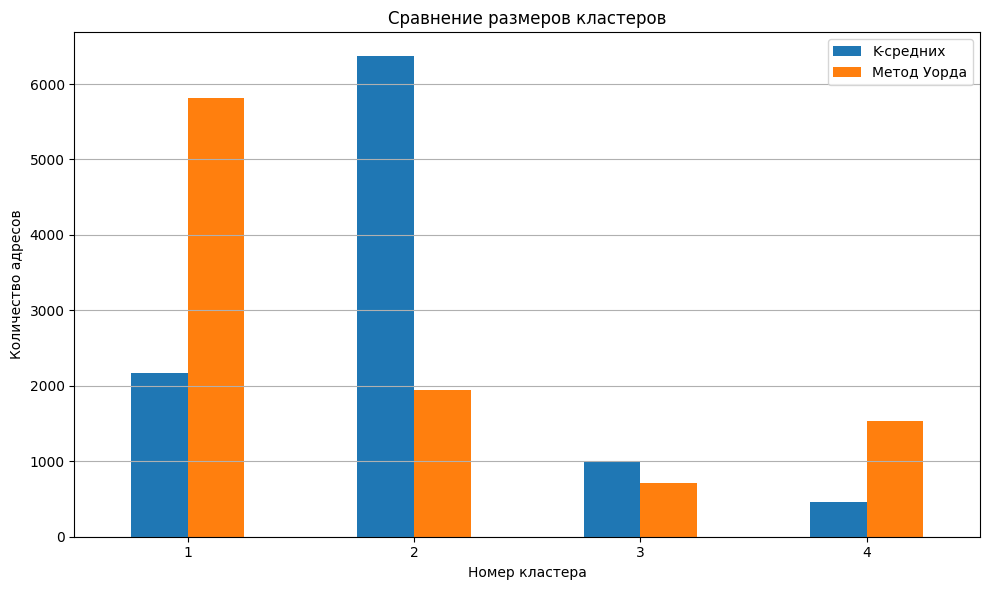

In [ ]:
cluster_sizes = pd.DataFrame({
    'Кластер': list(range(1, N_CLUSTERS + 1)),
    'K-средних': [
        int(np.sum(kmeans_labels == cluster))
        for cluster in range(1, N_CLUSTERS + 1)
    ],
    'Метод Уорда': [
        int(np.sum(ward_labels == cluster))
        for cluster in range(1, N_CLUSTERS + 1)
    ]
})

display(cluster_sizes)
cluster_sizes.to_csv('comparison_cluster_sizes.csv', index=False)

cluster_sizes.set_index('Кластер').plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Сравнение размеров кластеров')
plt.xlabel('Номер кластера')
plt.ylabel('Количество адресов')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('comparison_cluster_sizes.png', dpi=200, bbox_inches='tight')
plt.show()


### Распределение известных фишинговых адресов

Метка фишинга используется только после кластеризации.

In [ ]:
label_column = 'label' if 'label' in df_comparison.columns else 'isp'

df_comparison['cluster_kmeans'] = kmeans_labels
df_comparison['cluster_ward'] = ward_labels

def create_phishing_summary(data, cluster_column, label_column):
    summary = (
        data.groupby(cluster_column)
        .agg(
            total_addresses=(label_column, 'size'),
            phishing_addresses=(label_column, 'sum')
        )
        .reset_index()
        .rename(columns={cluster_column: 'cluster'})
    )

    summary['phishing_share_percent'] = (
        summary['phishing_addresses']
        / summary['total_addresses']
        * 100
    )

    total_phishing = data[label_column].sum()
    overall_phishing_share = data[label_column].mean()

    summary['share_of_all_phishing_percent'] = np.where(
        total_phishing > 0,
        summary['phishing_addresses'] / total_phishing * 100,
        0
    )

    summary['enrichment_coefficient'] = np.where(
        overall_phishing_share > 0,
        (summary['phishing_addresses'] / summary['total_addresses'])
        / overall_phishing_share,
        0
    )

    return summary.round(4)

kmeans_phishing_summary = create_phishing_summary(
    df_comparison,
    'cluster_kmeans',
    label_column
)

ward_phishing_summary = create_phishing_summary(
    df_comparison,
    'cluster_ward',
    label_column
)

print('K-средних')
display(kmeans_phishing_summary)

print('Метод Уорда')
display(ward_phishing_summary)

kmeans_phishing_summary.to_csv('comparison_kmeans_phishing.csv', index=False)
ward_phishing_summary.to_csv('comparison_ward_phishing.csv', index=False)


K-средних


,cluster,total_addresses,phishing_addresses,phishing_share_percent,share_of_all_phishing_percent,enrichment_coefficient
0,1,2169,52,2.3974,27.8075,1.2820
1,2,6367,29,0.4555,15.5080,0.2436
2,3,1003,50,4.9850,26.7380,2.6658
3,4,461,56,12.1475,29.9465,6.4960


Метод Уорда


,cluster,total_addresses,phishing_addresses,phishing_share_percent,share_of_all_phishing_percent,enrichment_coefficient
0,1,5819,16,0.2750,8.5561,0.1470
1,2,1939,64,3.3007,34.2246,1.7651
2,3,706,72,10.1983,38.5027,5.4536
3,4,1536,35,2.2786,18.7166,1.2185


### Сравнение концентрации фишинга

In [ ]:
phishing_comparison = pd.DataFrame({
    'Метод': ['K-средних', 'Метод Уорда'],
    'Максимальная доля фишинга, %': [
        kmeans_phishing_summary['phishing_share_percent'].max(),
        ward_phishing_summary['phishing_share_percent'].max()
    ],
    'Максимальный коэффициент обогащения': [
        kmeans_phishing_summary['enrichment_coefficient'].max(),
        ward_phishing_summary['enrichment_coefficient'].max()
    ]
})

display(phishing_comparison.round(4))
phishing_comparison.to_csv('comparison_phishing_concentration.csv', index=False)


,Метод,"Максимальная доля фишинга, %",Максимальный коэффициент обогащения
0,K-средних,12.1475,6.4960
1,Метод Уорда,10.1983,5.4536


### PCA-визуализация разбиений

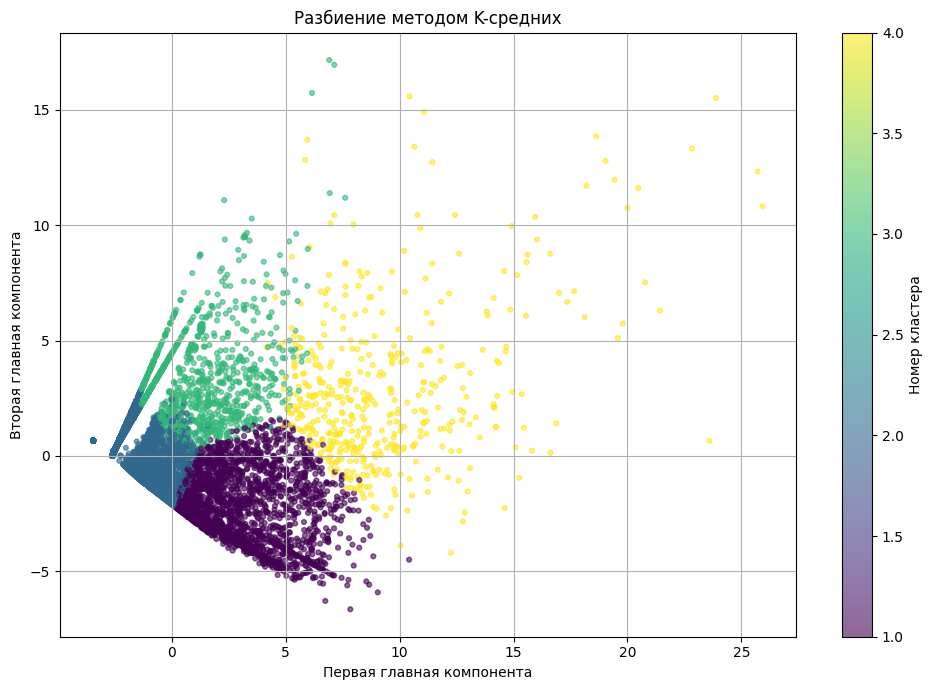

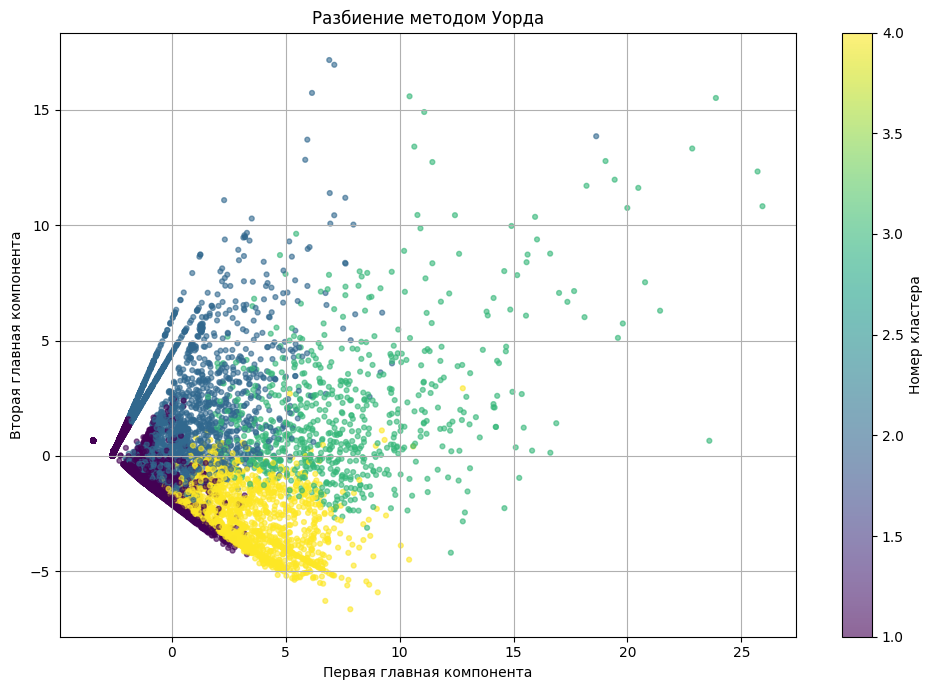

In [ ]:
pca_comparison = PCA(n_components=2, random_state=RANDOM_STATE)
X_comparison_pca = pca_comparison.fit_transform(X_comparison)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_comparison_pca[:, 0],
    X_comparison_pca[:, 1],
    c=kmeans_labels,
    s=12,
    alpha=0.6
)
plt.title('Разбиение методом K-средних')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.colorbar(scatter, label='Номер кластера')
plt.grid(True)
plt.tight_layout()
plt.savefig('comparison_kmeans_pca.png', dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_comparison_pca[:, 0],
    X_comparison_pca[:, 1],
    c=ward_labels,
    s=12,
    alpha=0.6
)
plt.title('Разбиение методом Уорда')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.colorbar(scatter, label='Номер кластера')
plt.grid(True)
plt.tight_layout()
plt.savefig('comparison_ward_pca.png', dpi=200, bbox_inches='tight')
plt.show()


### Профили кластеров двух методов

In [ ]:
scaled_comparison_df = pd.DataFrame(
    X_comparison,
    columns=comparison_feature_cols
)

scaled_comparison_df['cluster_kmeans'] = kmeans_labels
scaled_comparison_df['cluster_ward'] = ward_labels

kmeans_profiles_comparison = (
    scaled_comparison_df
    .groupby('cluster_kmeans')[comparison_feature_cols]
    .mean()
)

ward_profiles_comparison = (
    scaled_comparison_df
    .groupby('cluster_ward')[comparison_feature_cols]
    .mean()
)

print('Профили K-средних')
display(kmeans_profiles_comparison.round(3))

print('Профили метода Уорда')
display(ward_profiles_comparison.round(3))

kmeans_profiles_comparison.to_csv('comparison_kmeans_profiles.csv')
ward_profiles_comparison.to_csv('comparison_ward_profiles.csv')


Профили K-средних


,in_count,out_count,total_count,in_sum,out_sum,total_sum,in_mean,out_mean,in_std,out_std,...,out_max,in_degree,out_degree,total_degree,unique_predecessors,unique_successors,unique_neighbors,time_span,in_time_std,out_time_std
cluster_kmeans,,,,,,,,,,,,,,,,,,,,,
1,1.000,1.012,1.233,0.195,-0.012,0.150,-0.094,-0.257,0.068,-0.015,...,-0.080,1.000,1.012,1.233,0.929,1.055,1.239,1.074,1.239,1.021
2,-0.476,-0.410,-0.522,-0.431,-0.327,-0.460,-0.352,-0.229,-0.304,-0.238,...,-0.312,-0.476,-0.410,-0.522,-0.456,-0.403,-0.513,-0.464,-0.538,-0.372
3,0.029,-0.462,-0.245,0.944,0.698,1.218,1.474,1.279,0.458,0.253,...,0.863,0.029,-0.462,-0.245,0.080,-0.459,-0.238,0.071,0.034,-0.420
4,1.770,1.800,1.829,2.955,3.011,2.977,2.035,1.492,3.012,2.904,...,2.745,1.770,1.800,1.829,1.673,1.533,1.687,1.096,1.496,1.211


Профили метода Уорда


,in_count,out_count,total_count,in_sum,out_sum,total_sum,in_mean,out_mean,in_std,out_std,...,out_max,in_degree,out_degree,total_degree,unique_predecessors,unique_successors,unique_neighbors,time_span,in_time_std,out_time_std
cluster_ward,,,,,,,,,,,,,,,,,,,,,
1,-0.539,-0.308,-0.485,-0.474,-0.357,-0.517,-0.402,-0.284,-0.320,-0.252,...,-0.351,-0.539,-0.308,-0.485,-0.512,-0.296,-0.465,-0.477,-0.656,-0.275
2,0.074,-0.453,-0.189,0.482,0.341,0.695,0.783,0.708,0.233,0.100,...,0.456,0.074,-0.453,-0.189,0.098,-0.459,-0.205,0.167,0.198,-0.431
3,1.459,1.550,1.506,2.329,2.252,2.282,1.600,0.997,2.194,2.122,...,2.027,1.459,1.550,1.506,1.394,1.332,1.394,1.072,1.478,1.245
4,1.267,0.994,1.352,0.106,-0.125,0.029,-0.220,-0.304,-0.052,-0.117,...,-0.195,1.267,0.994,1.352,1.151,1.067,1.354,1.071,1.550,0.999


## Добавление DBSCAN и сравнение трёх методов

DBSCAN не требует заранее задавать количество кластеров. Алгоритм формирует кластеры на основе плотности объектов, а точки, не принадлежащие достаточно плотным областям, помечает как шум с меткой `-1`. Для сопоставимости DBSCAN применяется к той же стандартизированной подвыборке, что K-средних и метод Уорда. Метка фишинга не участвует в построении кластеров.

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import seaborn as sns

# Параметры DBSCAN можно скорректировать после анализа k-distance-графика.
DBSCAN_MIN_SAMPLES = max(5, 2 * X_comparison.shape[1])

print('min_samples для DBSCAN:', DBSCAN_MIN_SAMPLES)


min_samples для DBSCAN: 46


### Подбор параметра eps по графику расстояния до ближайших соседей

На графике выбирается область перегиба: после неё расстояния начинают резко возрастать. Значение по вертикали около перегиба может быть использовано как `eps`.

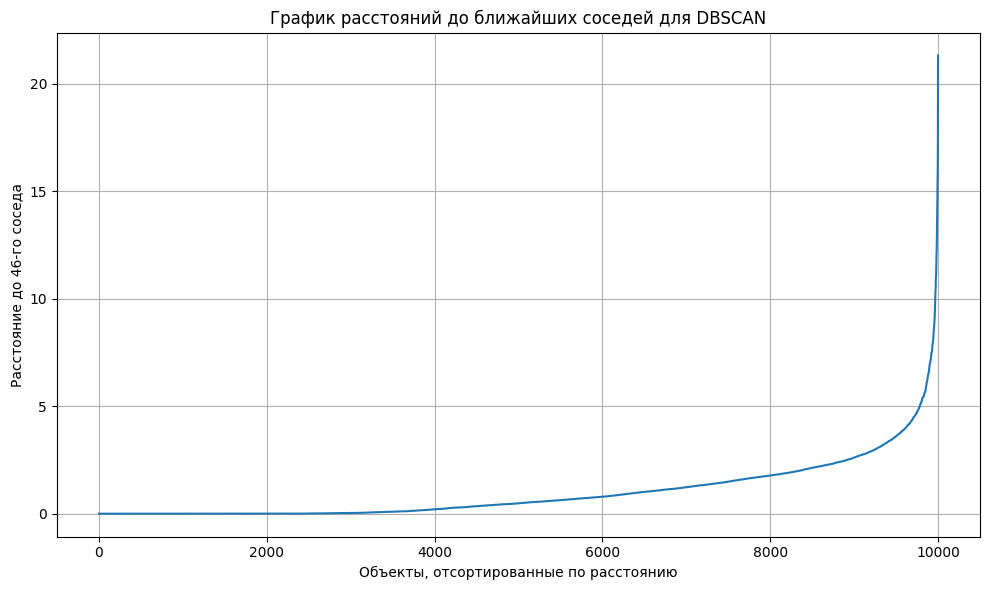

In [ ]:
neighbors_model = NearestNeighbors(n_neighbors=DBSCAN_MIN_SAMPLES)
neighbors_model.fit(X_comparison)
neighbor_distances, _ = neighbors_model.kneighbors(X_comparison)

k_distances = np.sort(neighbor_distances[:, -1])

plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.title('График расстояний до ближайших соседей для DBSCAN')
plt.xlabel('Объекты, отсортированные по расстоянию')
plt.ylabel(f'Расстояние до {DBSCAN_MIN_SAMPLES}-го соседа')
plt.grid(True)
plt.tight_layout()
plt.savefig('dbscan_k_distance.png', dpi=200, bbox_inches='tight')
plt.show()


### Перебор eps и выбор рабочего варианта

Кандидаты `eps` формируются по квантилям распределения расстояний. В итоговую таблицу включаются число кластеров, доля шума и внутренние метрики. Варианты с одним кластером не оцениваются силуэтным коэффициентом.

In [ ]:
eps_candidates = np.unique(np.round(
    np.quantile(k_distances, [0.70, 0.75, 0.80, 0.85, 0.90, 0.92, 0.94, 0.96, 0.98]),
    4
))

dbscan_search_rows = []

for eps_value in eps_candidates:
    model = DBSCAN(eps=float(eps_value), min_samples=DBSCAN_MIN_SAMPLES)
    labels = model.fit_predict(X_comparison)

    cluster_labels_without_noise = set(labels) - {-1}
    n_clusters_found = len(cluster_labels_without_noise)
    noise_share = float(np.mean(labels == -1))

    non_noise_mask = labels != -1
    labels_non_noise = labels[non_noise_mask]
    X_non_noise = X_comparison[non_noise_mask]

    silhouette = np.nan
    davies_bouldin = np.nan
    calinski_harabasz = np.nan

    if n_clusters_found >= 2 and len(X_non_noise) > n_clusters_found:
        silhouette = silhouette_score(X_non_noise, labels_non_noise)
        davies_bouldin = davies_bouldin_score(X_non_noise, labels_non_noise)
        calinski_harabasz = calinski_harabasz_score(X_non_noise, labels_non_noise)

    dbscan_search_rows.append({
        'eps': float(eps_value),
        'min_samples': DBSCAN_MIN_SAMPLES,
        'clusters_without_noise': n_clusters_found,
        'noise_share_percent': noise_share * 100,
        'silhouette_score_without_noise': silhouette,
        'davies_bouldin_without_noise': davies_bouldin,
        'calinski_harabasz_without_noise': calinski_harabasz
    })

dbscan_search = pd.DataFrame(dbscan_search_rows).round(4)
display(dbscan_search)
dbscan_search.to_csv('dbscan_parameter_search.csv', index=False)


,eps,min_samples,clusters_without_noise,noise_share_percent,silhouette_score_without_noise,davies_bouldin_without_noise,calinski_harabasz_without_noise
0,1.2331,46,3,22.93,-0.0398,0.7848,421.2906
1,1.4917,46,3,17.50,0.5033,0.4347,491.4564
2,1.7725,46,2,12.96,0.6432,0.3945,986.8320
3,2.1350,46,2,8.20,0.6038,0.4721,1046.5770
4,2.6109,46,1,5.05,NaN,NaN,NaN
5,2.9020,46,1,3.92,NaN,NaN,NaN
6,3.3413,46,1,2.54,NaN,NaN,NaN
7,3.9340,46,1,1.51,NaN,NaN,NaN
8,5.1791,46,1,0.68,NaN,NaN,NaN


### Автоматический выбор параметров DBSCAN

Предпочтение отдаётся варианту с числом кластеров, наиболее близким к четырём, разумной долей шума и высоким силуэтным коэффициентом. После просмотра таблицы значение `DBSCAN_EPS` можно заменить вручную.

In [ ]:
valid_dbscan = dbscan_search.dropna(subset=['silhouette_score_without_noise']).copy()

if valid_dbscan.empty:
    raise ValueError(
        'DBSCAN не сформировал минимум два кластера. '
        'Расширьте диапазон eps или уменьшите min_samples.'
    )

valid_dbscan['distance_from_four_clusters'] = (
    valid_dbscan['clusters_without_noise'] - N_CLUSTERS
).abs()

valid_dbscan['excessive_noise_penalty'] = np.where(
    valid_dbscan['noise_share_percent'] > 40,
    valid_dbscan['noise_share_percent'] - 40,
    0
)

valid_dbscan = valid_dbscan.sort_values(
    by=[
        'distance_from_four_clusters',
        'excessive_noise_penalty',
        'silhouette_score_without_noise'
    ],
    ascending=[True, True, False]
)

DBSCAN_EPS = float(valid_dbscan.iloc[0]['eps'])

print('Автоматически выбран eps:', DBSCAN_EPS)
print('После анализа таблицы это значение можно изменить вручную.')


Автоматически выбран eps: 1.4917
После анализа таблицы это значение можно изменить вручную.


### Итоговая кластеризация DBSCAN

In [ ]:
start_time = time.perf_counter()

dbscan_model = DBSCAN(
    eps=DBSCAN_EPS,
    min_samples=DBSCAN_MIN_SAMPLES
)

dbscan_labels_original = dbscan_model.fit_predict(X_comparison)
dbscan_time = time.perf_counter() - start_time

# Для отображения обычные кластеры перенумеровываются с 1.
# Шум сохраняет метку -1.
unique_dbscan_clusters = sorted(set(dbscan_labels_original) - {-1})
dbscan_label_mapping = {
    old_label: new_label
    for new_label, old_label in enumerate(unique_dbscan_clusters, start=1)
}

dbscan_labels = np.array([
    -1 if label == -1 else dbscan_label_mapping[label]
    for label in dbscan_labels_original
])

DBSCAN_N_CLUSTERS = len(unique_dbscan_clusters)
DBSCAN_NOISE_SHARE = np.mean(dbscan_labels == -1) * 100

print('Число кластеров DBSCAN без шума:', DBSCAN_N_CLUSTERS)
print('Доля шума:', round(DBSCAN_NOISE_SHARE, 2), '%')
print('Время выполнения:', round(dbscan_time, 4), 'с')


Число кластеров DBSCAN без шума: 3
Доля шума: 17.5 %
Время выполнения: 0.4753 с


### Общая таблица качества трёх методов

Для DBSCAN внутренние метрики рассчитываются только по объектам, отнесённым к кластерам; шум исключается из расчёта. Поэтому вместе с метриками обязательно учитывается доля шума.

In [ ]:
dbscan_non_noise_mask = dbscan_labels != -1
X_dbscan_non_noise = X_comparison[dbscan_non_noise_mask]
dbscan_labels_non_noise = dbscan_labels[dbscan_non_noise_mask]

if len(np.unique(dbscan_labels_non_noise)) >= 2:
    dbscan_silhouette = silhouette_score(
        X_dbscan_non_noise,
        dbscan_labels_non_noise
    )
    dbscan_db = davies_bouldin_score(
        X_dbscan_non_noise,
        dbscan_labels_non_noise
    )
    dbscan_ch = calinski_harabasz_score(
        X_dbscan_non_noise,
        dbscan_labels_non_noise
    )
else:
    dbscan_silhouette = np.nan
    dbscan_db = np.nan
    dbscan_ch = np.nan

comparison_three_methods = pd.DataFrame({
    'Метод': ['K-средних', 'Метод Уорда', 'DBSCAN'],
    'Число кластеров без шума': [N_CLUSTERS, N_CLUSTERS, DBSCAN_N_CLUSTERS],
    'Доля шума, %': [0.0, 0.0, DBSCAN_NOISE_SHARE],
    'Silhouette score': [
        silhouette_score(X_comparison, kmeans_labels_zero),
        silhouette_score(X_comparison, ward_labels_zero),
        dbscan_silhouette
    ],
    'Davies-Bouldin': [
        davies_bouldin_score(X_comparison, kmeans_labels_zero),
        davies_bouldin_score(X_comparison, ward_labels_zero),
        dbscan_db
    ],
    'Calinski-Harabasz': [
        calinski_harabasz_score(X_comparison, kmeans_labels_zero),
        calinski_harabasz_score(X_comparison, ward_labels_zero),
        dbscan_ch
    ],
    'Время, секунд': [kmeans_time, ward_time, dbscan_time]
})

comparison_three_methods = comparison_three_methods.round(4)
display(comparison_three_methods)
comparison_three_methods.to_csv('comparison_three_methods_metrics.csv', index=False)


,Метод,Число кластеров без шума,"Доля шума, %",Silhouette score,Davies-Bouldin,Calinski-Harabasz,"Время, секунд"
0,K-средних,4,0.0,0.4297,1.3706,3455.4374,0.2829
1,Метод Уорда,4,0.0,0.3471,1.5938,2819.3296,5.0303
2,DBSCAN,3,17.5,0.5033,0.4347,491.4564,0.4753


### Балльное сравнение трёх методов

Баллы являются вспомогательным ориентиром. Для DBSCAN дополнительно вводится штраф, если доля шума превышает 40 %. Окончательный вывод должен учитывать также интерпретируемость кластеров и концентрацию фишинговых адресов.

In [ ]:
three_methods_scored = comparison_three_methods.copy()
three_methods_scored['Баллы'] = 0

valid_metric_rows = three_methods_scored.dropna(subset=['Silhouette score'])

three_methods_scored.loc[
    valid_metric_rows['Silhouette score'].idxmax(), 'Баллы'
] += 1
three_methods_scored.loc[
    valid_metric_rows['Davies-Bouldin'].idxmin(), 'Баллы'
] += 1
three_methods_scored.loc[
    valid_metric_rows['Calinski-Harabasz'].idxmax(), 'Баллы'
] += 1
three_methods_scored.loc[
    three_methods_scored['Время, секунд'].idxmin(), 'Баллы'
] += 1

three_methods_scored['Штраф за шум'] = np.where(
    three_methods_scored['Доля шума, %'] > 40,
    1,
    0
)
three_methods_scored['Итоговые баллы'] = (
    three_methods_scored['Баллы']
    - three_methods_scored['Штраф за шум']
)

display(three_methods_scored)

winner_three = three_methods_scored.loc[
    three_methods_scored['Итоговые баллы'].idxmax(),
    'Метод'
]

print('По вспомогательной балльной оценке лучший метод:', winner_three)
three_methods_scored.to_csv('comparison_three_methods_scored.csv', index=False)


,Метод,Число кластеров без шума,"Доля шума, %",Silhouette score,Davies-Bouldin,Calinski-Harabasz,"Время, секунд",Баллы,Штраф за шум,Итоговые баллы
0,K-средних,4,0.0,0.4297,1.3706,3455.4374,0.2829,2,0,2
1,Метод Уорда,4,0.0,0.3471,1.5938,2819.3296,5.0303,0,0,0
2,DBSCAN,3,17.5,0.5033,0.4347,491.4564,0.4753,2,0,2


По вспомогательной балльной оценке лучший метод: K-средних


## Одинаковые визуализации для всех трёх методов

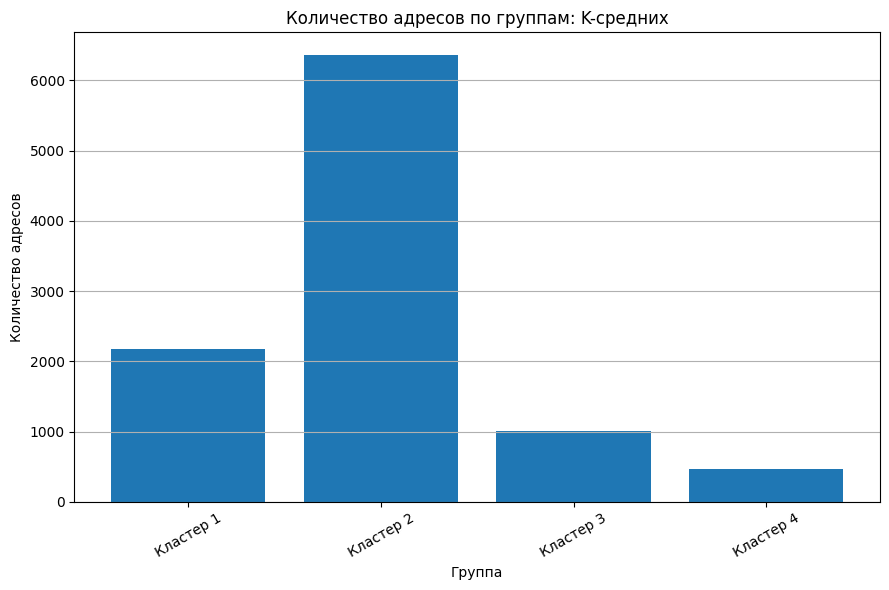

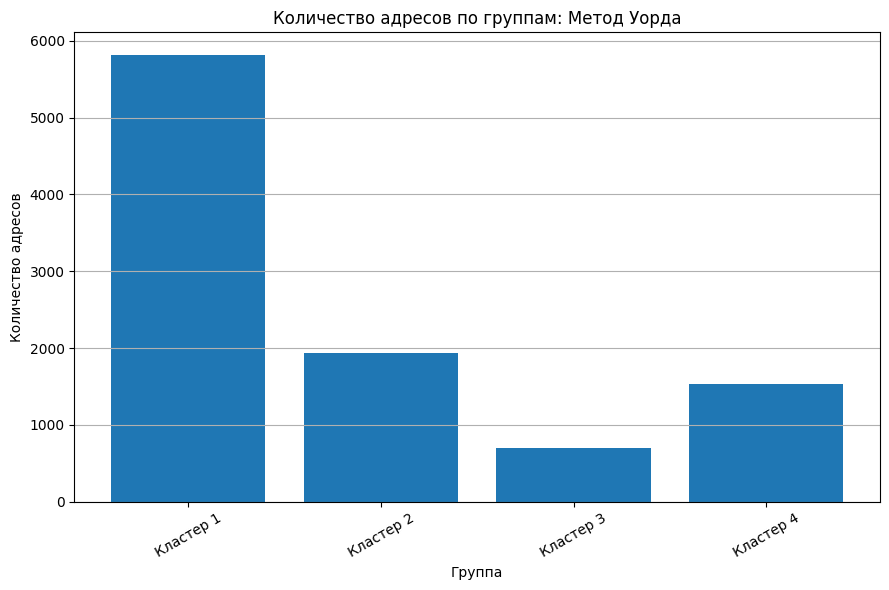

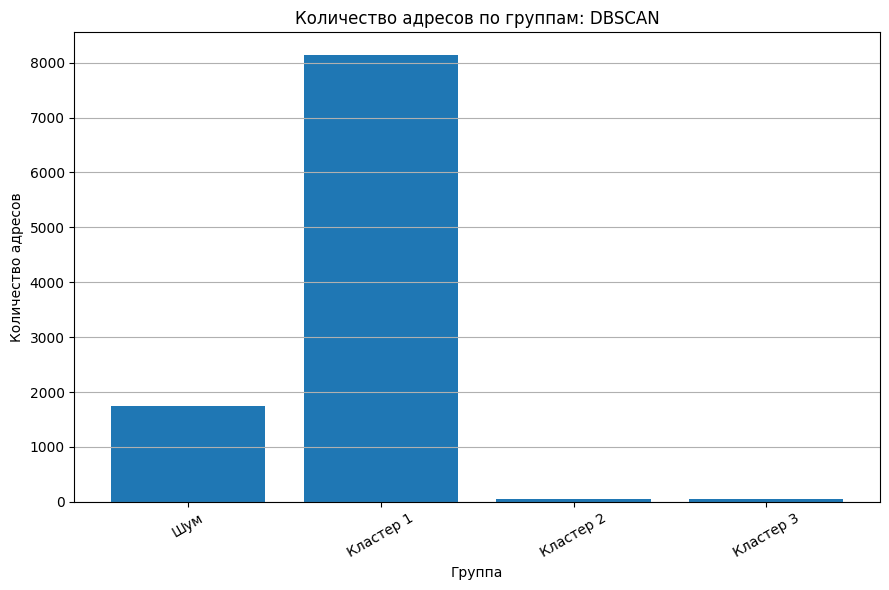

In [ ]:
df_comparison['cluster_dbscan'] = dbscan_labels

def plot_cluster_sizes(labels, method_name, filename):
    values, counts = np.unique(labels, return_counts=True)
    display_labels = ['Шум' if value == -1 else f'Кластер {value}' for value in values]

    plt.figure(figsize=(9, 6))
    plt.bar(display_labels, counts)
    plt.title(f'Количество адресов по группам: {method_name}')
    plt.xlabel('Группа')
    plt.ylabel('Количество адресов')
    plt.xticks(rotation=30)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches='tight')
    plt.show()

plot_cluster_sizes(kmeans_labels, 'K-средних', 'kmeans_cluster_sizes.png')
plot_cluster_sizes(ward_labels, 'Метод Уорда', 'ward_cluster_sizes.png')
plot_cluster_sizes(dbscan_labels, 'DBSCAN', 'dbscan_cluster_sizes.png')


### Таблицы и графики распределения фишинговых адресов

DBSCAN


,cluster,total_addresses,phishing_addresses,phishing_share_percent,share_of_all_phishing_percent,enrichment_coefficient
0,-1,1750,125,7.1429,66.8449,3.8197
1,1,8145,60,0.7366,32.0856,0.3939
2,2,58,2,3.4483,1.0695,1.8440
3,3,47,0,0.0000,0.0000,0.0000


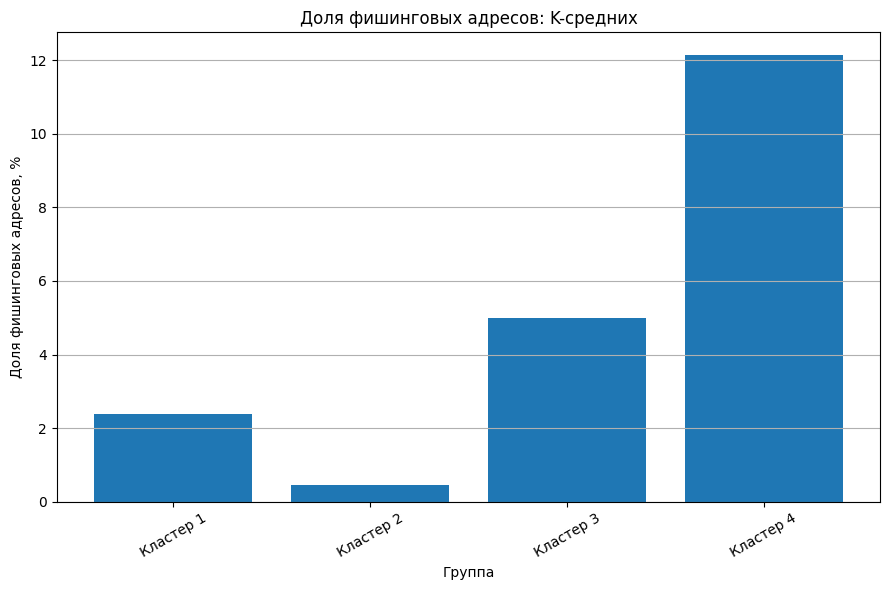

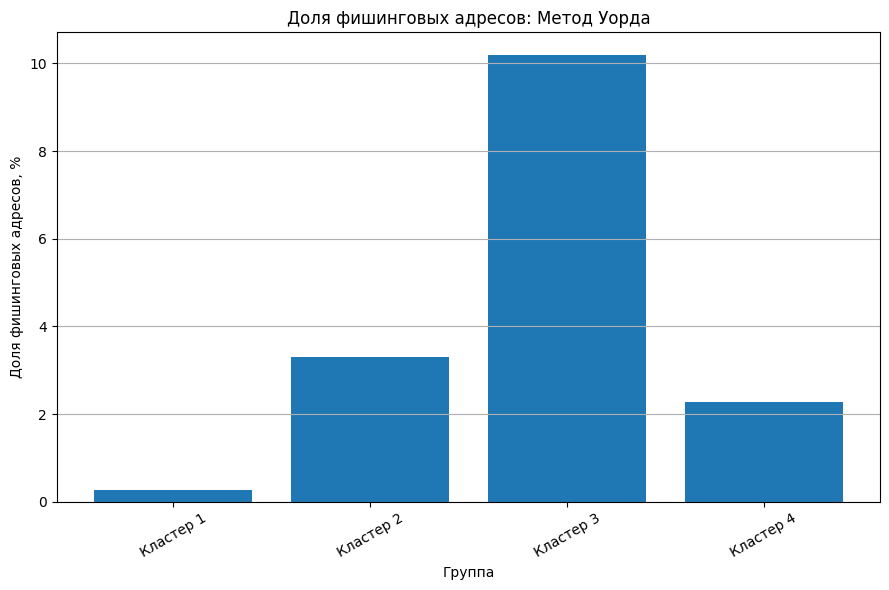

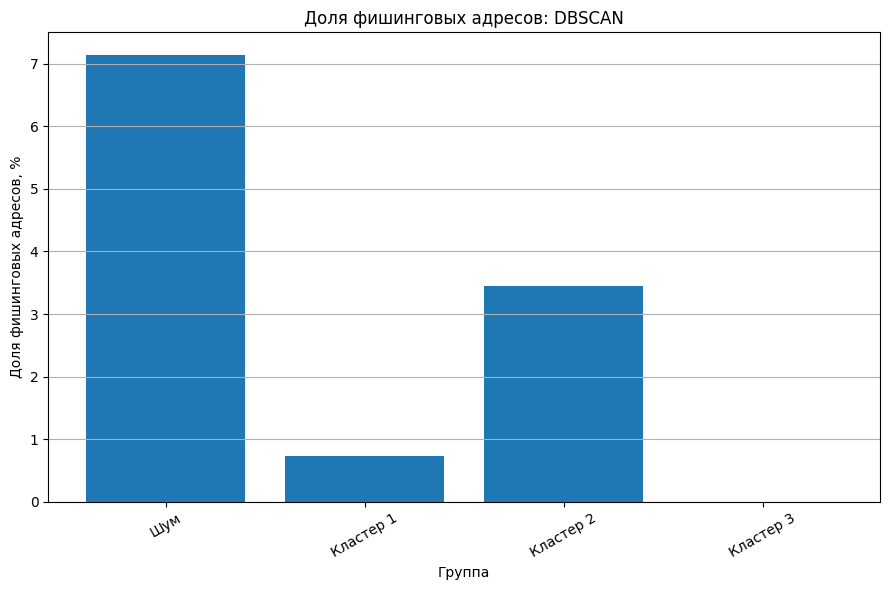

In [ ]:
dbscan_phishing_summary = create_phishing_summary(
    df_comparison,
    'cluster_dbscan',
    label_column
)

print('DBSCAN')
display(dbscan_phishing_summary)
dbscan_phishing_summary.to_csv('comparison_dbscan_phishing.csv', index=False)

def plot_phishing_share(summary, method_name, filename):
    labels = [
        'Шум' if cluster == -1 else f'Кластер {int(cluster)}'
        for cluster in summary['cluster']
    ]

    plt.figure(figsize=(9, 6))
    plt.bar(labels, summary['phishing_share_percent'])
    plt.title(f'Доля фишинговых адресов: {method_name}')
    plt.xlabel('Группа')
    plt.ylabel('Доля фишинговых адресов, %')
    plt.xticks(rotation=30)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches='tight')
    plt.show()

plot_phishing_share(
    kmeans_phishing_summary,
    'K-средних',
    'kmeans_phishing_share.png'
)
plot_phishing_share(
    ward_phishing_summary,
    'Метод Уорда',
    'ward_phishing_share.png'
)
plot_phishing_share(
    dbscan_phishing_summary,
    'DBSCAN',
    'dbscan_phishing_share.png'
)


### PCA-визуализации всех трёх разбиений

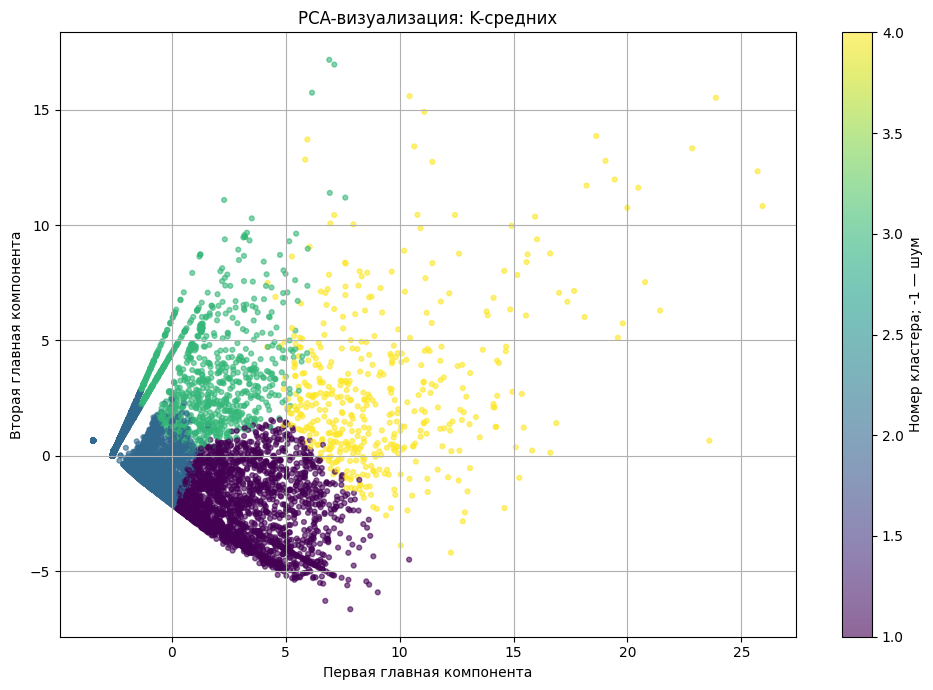

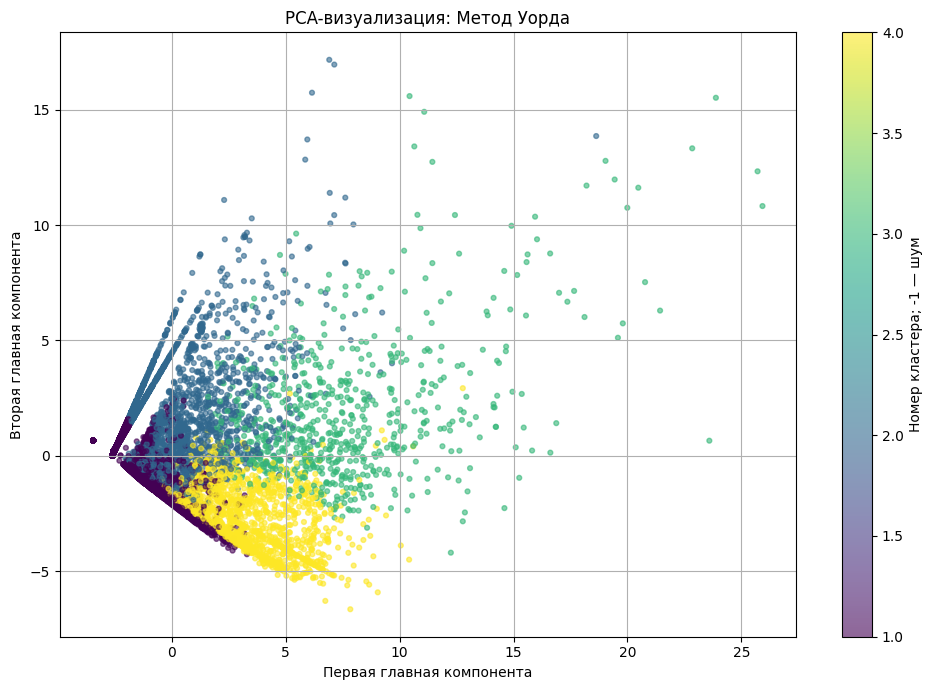

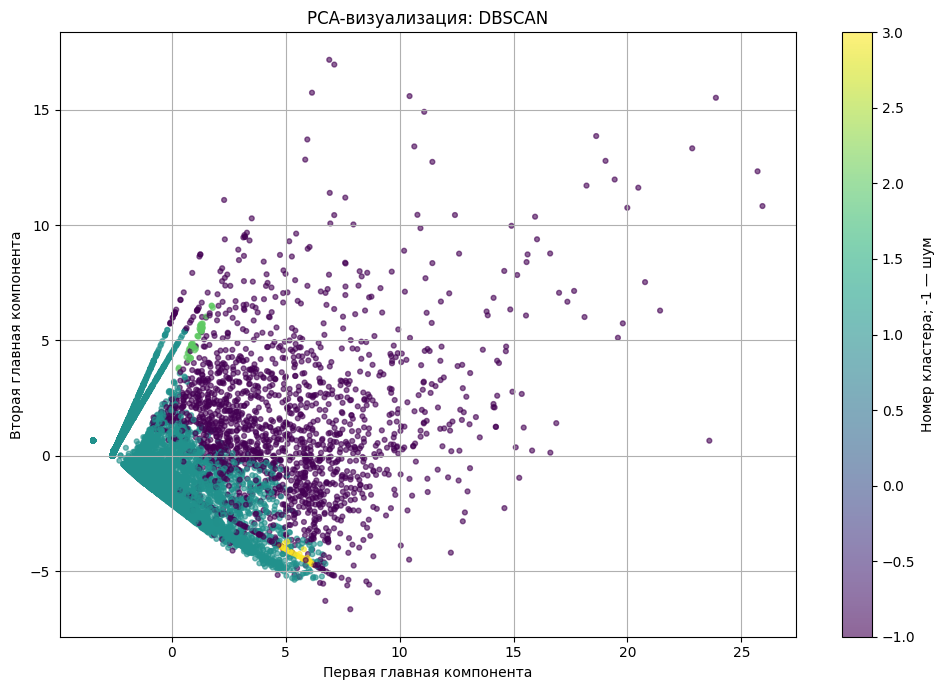

In [ ]:
def plot_pca_clusters(X_pca, labels, method_name, filename):
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels,
        s=12,
        alpha=0.6
    )
    plt.title(f'PCA-визуализация: {method_name}')
    plt.xlabel('Первая главная компонента')
    plt.ylabel('Вторая главная компонента')
    plt.colorbar(scatter, label='Номер кластера; -1 — шум')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches='tight')
    plt.show()

plot_pca_clusters(
    X_comparison_pca,
    kmeans_labels,
    'K-средних',
    'kmeans_pca_equal.png'
)
plot_pca_clusters(
    X_comparison_pca,
    ward_labels,
    'Метод Уорда',
    'ward_pca_equal.png'
)
plot_pca_clusters(
    X_comparison_pca,
    dbscan_labels,
    'DBSCAN',
    'dbscan_pca.png'
)


### Профили кластеров и тепловые карты

Профили DBSCAN


,in_count,out_count,total_count,in_sum,out_sum,total_sum,in_mean,out_mean,in_std,out_std,...,out_max,in_degree,out_degree,total_degree,unique_predecessors,unique_successors,unique_neighbors,time_span,in_time_std,out_time_std
cluster_dbscan,,,,,,,,,,,,,,,,,,,,,
-1,1.204,0.744,1.143,1.501,1.312,1.638,1.107,0.875,1.297,1.112,...,1.237,1.204,0.744,1.143,1.051,0.592,0.954,0.925,1.072,0.593
1,-0.287,-0.158,-0.269,-0.328,-0.291,-0.357,-0.253,-0.210,-0.267,-0.230,...,-0.279,-0.287,-0.158,-0.269,-0.262,-0.123,-0.232,-0.211,-0.237,-0.119
2,-0.133,-0.414,-0.390,0.942,1.332,1.101,1.967,2.677,-0.320,-0.280,...,1.725,-0.133,-0.414,-0.390,0.048,-0.304,-0.227,-0.121,-0.658,-0.832
3,4.627,-0.972,3.525,-0.475,-0.460,-0.592,-0.459,-0.415,-0.317,-0.280,...,-0.463,4.627,-0.972,3.525,5.457,-1.041,4.070,1.201,1.685,-0.832


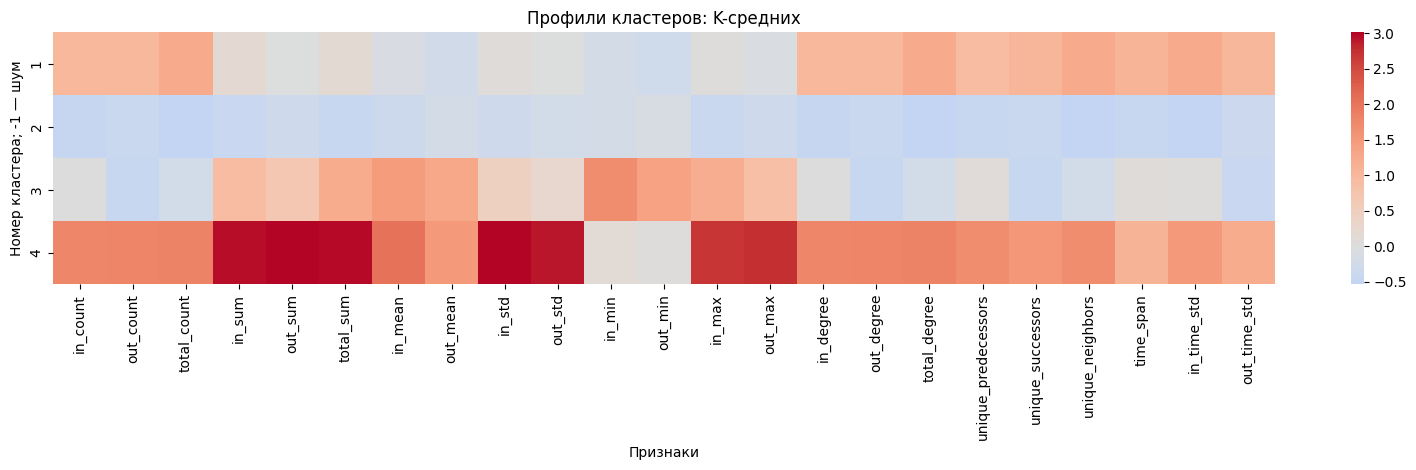

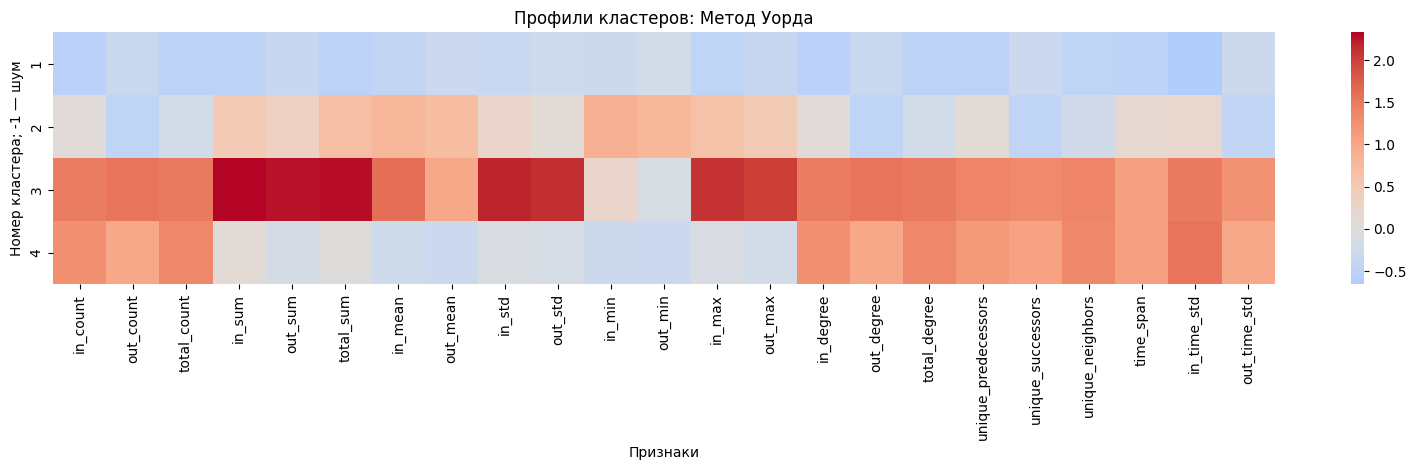

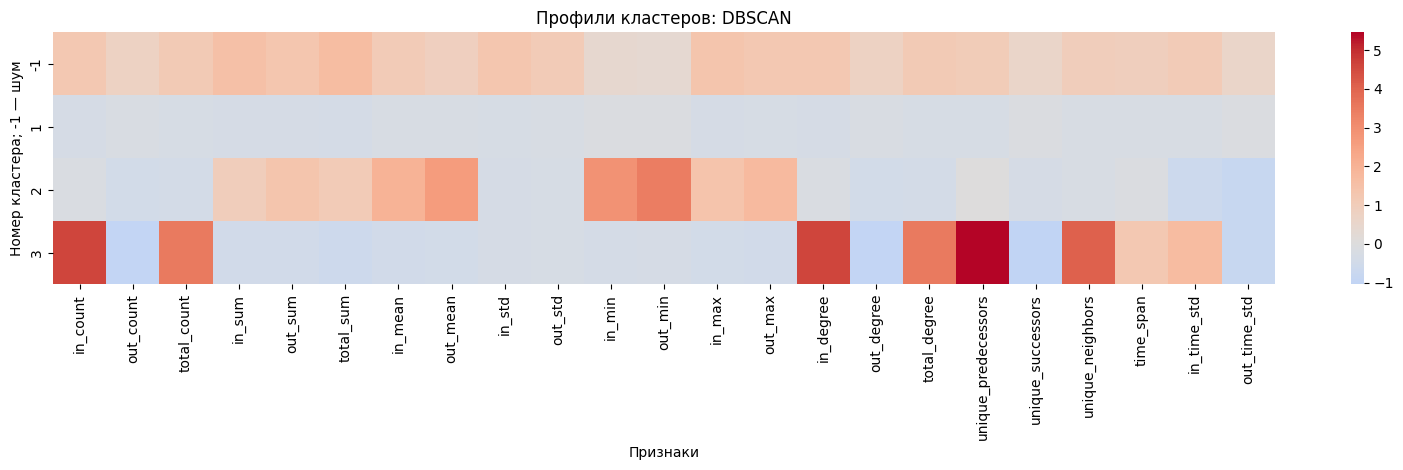

In [ ]:
scaled_comparison_df['cluster_dbscan'] = dbscan_labels

dbscan_profiles_comparison = (
    scaled_comparison_df
    .groupby('cluster_dbscan')[comparison_feature_cols]
    .mean()
)

print('Профили DBSCAN')
display(dbscan_profiles_comparison.round(3))
dbscan_profiles_comparison.to_csv('comparison_dbscan_profiles.csv')

def plot_profile_heatmap(profile_df, method_name, filename):
    plt.figure(figsize=(16, max(4, 1.2 * len(profile_df))))
    sns.heatmap(
        profile_df,
        cmap='coolwarm',
        center=0,
        annot=False
    )
    plt.title(f'Профили кластеров: {method_name}')
    plt.xlabel('Признаки')
    plt.ylabel('Номер кластера; -1 — шум')
    plt.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches='tight')
    plt.show()

plot_profile_heatmap(
    kmeans_profiles_comparison,
    'K-средних',
    'kmeans_profiles_heatmap.png'
)
plot_profile_heatmap(
    ward_profiles_comparison,
    'Метод Уорда',
    'ward_profiles_heatmap.png'
)
plot_profile_heatmap(
    dbscan_profiles_comparison,
    'DBSCAN',
    'dbscan_profiles_heatmap.png'
)


### Отличительные признаки каждого кластера для всех методов

In [ ]:
def top_distinctive_features(profile_df, top_n=8):
    rows = []
    for cluster_id, row in profile_df.iterrows():
        top_features = row.abs().sort_values(ascending=False).head(top_n).index
        for feature in top_features:
            rows.append({
                'cluster': cluster_id,
                'feature': feature,
                'standardized_mean': row[feature],
                'direction': 'выше среднего' if row[feature] > 0 else 'ниже среднего'
            })
    return pd.DataFrame(rows)

kmeans_top_features = top_distinctive_features(kmeans_profiles_comparison)
ward_top_features = top_distinctive_features(ward_profiles_comparison)
dbscan_top_features = top_distinctive_features(dbscan_profiles_comparison)

print('K-средних')
display(kmeans_top_features)
print('Метод Уорда')
display(ward_top_features)
print('DBSCAN')
display(dbscan_top_features)

kmeans_top_features.to_csv('kmeans_top_distinctive_features.csv', index=False)
ward_top_features.to_csv('ward_top_distinctive_features.csv', index=False)
dbscan_top_features.to_csv('dbscan_top_distinctive_features.csv', index=False)


K-средних


,cluster,feature,standardized_mean,direction
0,1,in_time_std,1.239073,выше среднего
1,1,unique_neighbors,1.238741,выше среднего
2,1,total_count,1.233110,выше среднего
3,1,total_degree,1.233110,выше среднего
4,1,time_span,1.073913,выше среднего
5,1,unique_successors,1.055309,выше среднего
6,1,out_time_std,1.020737,выше среднего
7,1,out_degree,1.011958,выше среднего
8,2,in_time_std,-0.537568,ниже среднего
9,2,total_degree,-0.521606,ниже среднего


Метод Уорда


,cluster,feature,standardized_mean,direction
0,1,in_time_std,-0.656236,ниже среднего
1,1,in_degree,-0.539268,ниже среднего
2,1,in_count,-0.539268,ниже среднего
3,1,total_sum,-0.517280,ниже среднего
4,1,unique_predecessors,-0.512269,ниже среднего
5,1,total_degree,-0.485195,ниже среднего
6,1,total_count,-0.485195,ниже среднего
7,1,time_span,-0.476570,ниже среднего
8,2,in_min,0.889398,выше среднего
9,2,out_min,0.790710,выше среднего


DBSCAN


,cluster,feature,standardized_mean,direction
0,-1,total_sum,1.637562,выше среднего
1,-1,in_sum,1.501471,выше среднего
2,-1,in_max,1.353223,выше среднего
3,-1,out_sum,1.311658,выше среднего
4,-1,in_std,1.297340,выше среднего
5,-1,out_max,1.236786,выше среднего
6,-1,in_count,1.204303,выше среднего
7,-1,in_degree,1.204303,выше среднего
8,1,total_sum,-0.357190,ниже среднего
9,1,in_sum,-0.328079,ниже среднего
